##  Low-cost Air Quality Sensor Calibration to improve their data quality.

### QMSP4-25 Abigail FRIMPONG

Import Global Libraries

In [1]:
# The necessary imports first
import os
os.environ["OMP_NUM_THREADS"] = '1'# Stops warnings about memory leaks from kmeans seen on some platforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from matplotlib import MatplotlibDeprecationWarning
%matplotlib inline
np.set_printoptions(precision=3, suppress=True, formatter={'float': lambda x:f'{x:7.3f}'}, linewidth=100)

In [2]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob

In [3]:
import os, sys, re, pickle, glob
import urllib.request
import zipfile

In [4]:
import IPython.display as ipd
from tqdm import tqdm
import librosa

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)
# warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)
from sklearn import datasets

In [6]:
!pip install librosa

In [7]:
print("Current Directory:", os.getcwd())

Current Directory: /content


In [8]:
from IPython.display import Image
Image(url = "https://scikit-learn.org/stable/_downloads/b82bf6cd7438a351f19fac60fbc0d927/ml_map.svg")

## Reading the original dataset

Here I check the content of my drive, specifically, if the latter contains the folder MSc Project and its content.

In [9]:
path = '/content/drive/MyDrive/Colab Notebooks/MSc Project'
os.listdir(path)

['Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master.zip',
 'Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master',
 'merged_outputs',
 'DATA',
 'Low-cost Air Quality Sensor Calibration to improve their data quality.ipynb',
 'Untitled2.jpg',
 'Untitled.jpg',
 'Untitled 3.jpg',
 'Updated Low-cost Air Quality Sensor Calibration to improve their data quality.ipynb',
 'video1848069110.mp4']

This code is for extracting (unzipping) all folders inside MSc Project folder

In [10]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master.zip'
print(os.path.exists(zip_path))

True


In [11]:
extract_to = '/content/drive/MyDrive/Colab Notebooks/MSc Project'
# Create extraction folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)
# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

Here I check the content of my unzipped folder Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master.zip

In [12]:
unzipped_folder='/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master'
os.listdir(unzipped_folder)

['node_3',
 'node_5',
 'DATA',
 'analysis_outputs',
 '.gitignore',
 'deployment_details.csv',
 'README.md',
 'data_dictionary.md',
 'sensor_specifications.csv']

In [13]:
Deploy_df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master/deployment_details.csv").set_index('node_id')
Deploy_df

,location,specific_location,location_type,environment,latitude,longitude,reference_station,reference_distance_m,available_sensors,deployment_notes
node_id,,,,,,,,,,
node_3,QMUL,Mile End Road,Outdoor,Roadside - Urban Traffic,51.522530,-0.042155,TH2 (QMUL Mile End Road),0m,"low_cost, mid_cost",Multi-tier sensor node co-located with referen...
node_5,King Edward Memorial Park,Glamis Rd & A1203,Outdoor,Roadside - Urban Traffic,51.509477,-0.050541,TH7 (King Edward Memorial Park),0m,"low_cost, mid_cost",Multi-tier sensor node co-located with referen...
node_TowerHamlets_TH2,QMUL,Mile End Road,Outdoor,Roadside - Urban Traffic,51.522530,-0.042155,Self,0m,high_cost,DEFRA/AURN reference station TH2 (QMUL Mile En...
node_TowerHamlets_TH7,King Edward Memorial Park,Glamis Rd & A1203,Outdoor,Roadside - Urban Traffic,51.509477,-0.050541,Self,0m,high_cost,DEFRA/AURN reference station TH7 (King Edward ...


In [14]:
# Read Sensor Specification file
Sensor_Spec = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master/sensor_specifications.csv")
Sensor_Spec

,node_id,location_type,cost_category,measurement,sensor_name,manufacturer,board_assembler
0,node_3,outdoor,low-cost,temperature/humidity,SHT45,Sensirion,Adafruit
1,node_3,outdoor,low-cost,voc_index,SGP40,Sensirion,Adafruit
2,node_3,outdoor,low-cost,co/no2,Grove Multichannel Gas Sensor v2,Winsen (chips),Seeed Studio
3,node_3,outdoor,low-cost,ozone,MQ131,Winsen,Generic board FC-22
4,node_3,outdoor,low-cost,pm2_5/pm10,SPS30,Sensirion,Sensirion
5,node_3,outdoor,mid-cost,co,Alphasense CO-B4,Alphasense,4-Electrode Individual Sensor Board (ISB)
6,node_3,outdoor,mid-cost,no2,Alphasense NO2-B43F,Alphasense,4-Electrode Individual Sensor Board (ISB)
7,node_3,outdoor,mid-cost,ozone,Alphasense OX-B431,Alphasense,4-Electrode Individual Sensor Board (ISB)
8,node_5,outdoor,low-cost,temperature/humidity,SHT45,Sensirion,Adafruit
9,node_5,outdoor,low-cost,voc_index,SGP40,Sensirion,Adafruit


In [15]:
from IPython.display import Markdown, display

# Read Data Dictionary file
with open("/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master/data_dictionary.md", "r") as f:
    Data_dict = f.read()

# Display
display(Markdown(Data_dict))

# Data Dictionary for Cost-Tier Comparison Project

## Overview
This document provides detailed information about the sensor data collected from nodes 3 and 5 for comparing low-cost, mid-cost, and high-cost air quality sensors.

**Data Collection Period:** April 16, 2025 to July 16, 2025

**Sensor Co-location:** All sensors are positioned within less than 1 meter of each other to ensure comparable measurements.

**Location Information:**
- **Node 3**: QMUL Mile End Road (51.522530, -0.042155) - co-located with TH2 reference station
- **Node 5**: King Edward Memorial Park (51.509477, -0.050541) - co-located with TH7 reference station
- **Environment**: Both locations are roadside urban traffic sites 

**Data Collection Frequencies:**
- **Low-cost and Mid-cost sensors**: 30 seconds
- **High-cost sensors (reference stations)**: 15 minutes
- **No resampling applied** - data preserved at original frequencies

**Missing Values:** Data is downloaded with original timestamps from database. Missing values occur naturally due to sensor interruptions and are preserved as gaps in the time series rather than filled with NaN.

**Timestamp Format:** All CSV files use London time (GMT/BST) with separate date and time columns:
- **Date format**: `YYYY-MM-DD` (e.g., `2025-04-15`)
- **Time format**: `HH:MM:SS` (e.g., `14:40:42`)
- **Timezone**: Europe/London (automatically handles GMT/BST transitions)

## CSV Files Structure
Each measurement type has its own CSV file within each cost tier folder:

**Low-cost sensors:**
- `node_3/low_cost/temperature.csv`
- `node_3/low_cost/humidity.csv`
- `node_3/low_cost/pm2_5.csv`
- etc.

**Mid-cost sensors (multi-column format):**
- `node_3/mid_cost/co_alphasense.csv` (op1_raw, op1_voltage, op2_raw, op2_voltage)
- `node_3/mid_cost/no2_alphasense.csv` (op1_raw, op1_voltage, op2_raw, op2_voltage)
- `node_3/mid_cost/ozone_alphasense.csv` (op1_raw, op1_voltage, op2_raw, op2_voltage)

**High-cost sensors:**
- `node_3/high_cost/no2.csv`
- `node_3/high_cost/pm2_5.csv`

## Column Descriptions

### Standard Columns

**Low-cost and High-cost sensors:**
- **`date`**: Date in YYYY-MM-DD format (London time)
- **`time`**: Time in HH:MM:SS format (London time)
- **`value`**: Sensor measurement value

**Mid-cost sensors (Alphasense):**
- **`date`**: Date in YYYY-MM-DD format (London time)
- **`time`**: Time in HH:MM:SS format (London time)
- **`op1_raw`**: Working electrode raw ADC value (0-65535)
- **`op1_voltage`**: Working electrode voltage (0-6144 mV)
- **`op2_raw`**: Auxiliary electrode raw ADC value (0-65535)
- **`op2_voltage`**: Auxiliary electrode voltage (0-6144 mV)

### Common Columns in All Files
| Column | Description | Data Type | Format | Example |
|--------|-------------|-----------|--------|---------|
| date | Date of measurement | String | YYYY-MM-DD | 2025-04-15 |
| time | Time of measurement | String | HH:MM:SS | 14:40:42 |
| value | Sensor measurement value | Numeric | Varies by sensor | 23.45 |

## Low-Cost Sensors (nodes 3 and 5)

### Environmental Measurements

#### Temperature (temperature.csv)
| Property | Value |
|----------|-------|
| **Sensor** | SHT45 (Sensirion) |
| **Units** | Degrees Celsius (°C) |
| **Range** | -40 to +125°C (sensor specification) |
| **Precision** | 2 decimal places |
| **Frequency** | 30 seconds |

#### Humidity (humidity.csv)
| Property | Value |
|----------|-------|
| **Sensor** | SHT45 (Sensirion) |
| **Units** | Percentage (%) |
| **Range** | 0 to 100% (sensor specification) |
| **Precision** | 2 decimal places |
| **Frequency** | 30 seconds |

### Particle Measurements

#### PM2.5 (particles_pm2_5.csv)
| Property | Value |
|----------|-------|
| **Sensor** | SPS30 (Sensirion) |
| **Units** | Micrograms per cubic meter (µg/m³) |
| **Range** | 0 to 1000 µg/m³ (sensor specification) |
| **Precision** | ±10% (sensor specification) |
| **Frequency** | 30 seconds |

#### PM10 (particles_pm10.csv)
| Property | Value |
|----------|-------|
| **Sensor** | SPS30 (Sensirion) |
| **Units** | Micrograms per cubic meter (µg/m³) |
| **Range** | 0 to 1000 µg/m³ (sensor specification) |
| **Precision** | ±10% (sensor specification) |
| **Frequency** | 30 seconds |

### Gas Measurements (Low-Cost)

#### Carbon Monoxide (co_raw.csv)
| Property | Value |
|----------|-------|
| **Sensor** | Grove Multichannel Gas v2 (GM702B) |
| **Units** | Raw sensor value |
| **Range** | 0 to 999 (sensor library limitation) |
| **Precision** | Integer |
| **Frequency** | 30 seconds |
| **Notes** | Requires calibration for ppm conversion |

#### Nitrogen Dioxide (no2_raw.csv)
| Property | Value |
|----------|-------|
| **Sensor** | Grove Multichannel Gas v2 (GM102B) |
| **Units** | Raw sensor value |
| **Range** | 0 to 999 (sensor library limitation) |
| **Precision** | Integer |
| **Frequency** | 30 seconds |
| **Notes** | Requires calibration for ppb conversion |

#### Ozone (ozone_raw.csv)
| Property | Value |
|----------|-------|
| **Sensor** | MQ131 (Winsen) |
| **Units** | Raw ADC value |
| **Range** | 0 to 65535 (16-bit ADC) |
| **Precision** | Integer |
| **Frequency** | 30 seconds |
| **Notes** | Requires calibration for ppm conversion. Connected via ADS1115 ADC |

#### VOC Index (voc.csv)
| Property | Value |
|----------|-------|
| **Sensor** | SGP40 (Sensirion) |
| **Units** | VOC Index |
| **Range** | 0 to 500 (sensor specification) |
| **Precision** | Integer |
| **Frequency** | 30 seconds |
| **Notes** | Temperature and humidity compensated |

## Mid-Cost Sensors (Alphasense - nodes 3 and 5)

### Electrochemical Gas Sensors

**Technical Overview:**
Alphasense electrochemical sensors use a **4-electrode configuration** for accurate gas detection:

- **OP1 (Working Electrode)**: Primary sensing electrode that responds to the target gas concentration. This electrode generates a current proportional to the gas concentration.
- **OP2 (Auxiliary/Counter Electrode)**: Reference electrode used for temperature compensation and baseline correction. It experiences the same environmental conditions but is not exposed to the target gas.

**Why Both Electrodes?**
- **Temperature Compensation**: Environmental temperature affects both electrodes similarly, allowing for compensation
- **Baseline Drift Correction**: The difference (OP1 - OP2) removes common-mode interference and sensor drift
- **Improved Accuracy**: Dual-electrode configuration significantly improves measurement precision compared to single-electrode sensors

**Data Processing**: For accurate gas concentration, you can use either format:

**Gas Concentration Calculation:**
```
Gas Concentration = (OP1_voltage - OP2_voltage) × Sensitivity_Factor
```

**Where:**
- **OP1_voltage**: Working electrode voltage (mV)
- **OP2_voltage**: Auxiliary electrode voltage (mV)  
- **Sensitivity_Factor**: Alphasense calibration constant (mV/ppm or mV/ppb)


#### CO Alphasense (co_alphasense.csv)
| Property | Value |
|----------|-------|
| **Sensor** | Alphasense CO-B4 |
| **Columns** | date, time, op1_raw, op1_voltage, op2_raw, op2_voltage |
| **Units** | Raw ADC (0-65535), Voltage (0-6144 mV) |
| **Precision** | Integer (raw), 5 decimals (voltage) |
| **Frequency** | 30 seconds |
| **Notes** | Multi-column format with both raw ADC and voltage values |

#### NO2 Alphasense (no2_alphasense.csv)
| Property | Value |
|----------|-------|
| **Sensor** | Alphasense NO2-B43F |
| **Columns** | date, time, op1_raw, op1_voltage, op2_raw, op2_voltage |
| **Units** | Raw ADC (0-65535), Voltage (0-6144 mV) |
| **Precision** | Integer (raw), 5 decimals (voltage) |
| **Frequency** | 30 seconds |
| **Notes** | Multi-column format with both raw ADC and voltage values |

#### Ozone Alphasense (ozone_alphasense.csv)
| Property | Value |
|----------|-------|
| **Sensor** | Alphasense OX-B431 |
| **Columns** | date, time, op1_raw, op1_voltage, op2_raw, op2_voltage |
| **Units** | Raw ADC (0-65535), Voltage (0-6144 mV) |
| **Precision** | Integer (raw), 5 decimals (voltage) |
| **Frequency** | 30 seconds |
| **Notes** | Multi-column format with both raw ADC and voltage values |

## High-Cost Sensors (Government Reference Stations)

### TH2 Station (co-located with Node 3)

#### NO2 Reference (no2.csv)
| Property | Value |
|----------|-------|
| **Station** | Tower Hamlets TH2 (DEFRA/AURN) |
| **Units** | Micrograms per cubic meter (µg/m³) |
| **Range** | TBD (reference station specification) |
| **Precision** | As reported by station |
| **Frequency** | 15 minutes |
| **QA/QC** | Continuous calibration and validation |

#### PM2.5 Reference (pm2_5.csv)
| Property | Value |
|----------|-------|
| **Station** | Tower Hamlets TH2 (DEFRA/AURN) |
| **Units** | Micrograms per cubic meter (µg/m³) |
| **Range** | TBD (reference station specification) |
| **Precision** | As reported by station |
| **Frequency** | 15 minutes |
| **QA/QC** | Continuous calibration and validation |

### TH7 Station (co-located with Node 5)

#### NO2 Reference (no2.csv)
| Property | Value |
|----------|-------|
| **Station** | Tower Hamlets TH7 (DEFRA/AURN) |
| **Units** | Micrograms per cubic meter (µg/m³) |
| **Range** | TBD (reference station specification) |
| **Precision** | As reported by station |
| **Frequency** | 15 minutes |
| **QA/QC** | Continuous calibration and validation |

#### PM2.5 Reference (pm2_5.csv)
| Property | Value |
|----------|-------|
| **Station** | Tower Hamlets TH7 (DEFRA/AURN) |
| **Units** | Micrograms per cubic meter (µg/m³) |
| **Range** | TBD (reference station specification) |
| **Precision** | As reported by station |
| **Frequency** | 15 minutes |
| **QA/QC** | Continuous calibration and validation |

## Data Quality and Processing Notes

### Temporal Information
- **Low/Mid-cost Frequency**: 30 seconds
- **High-cost Frequency**: 15 minutes  
- **Time Zone**: All timestamps in UTC
- **Period**: April 16, 2025 to July 16, 2025

### Data Processing
- **Missing Values**: Original timestamps preserved from database without artificial gap filling
- **No Resampling**: Data preserved at original collection frequencies and timestamps
- **Quality Control**: Basic sensor validation applied
- **Temporal Integrity**: Natural gaps due to sensor interruptions are preserved

### Calibration Status
- **Low-cost**: Factory calibration only, may require field correction
- **Mid-cost**: Raw readings, require post-processing with calibration curves
- **High-cost**: Fully calibrated and QA/QC validated reference measurements


In [16]:
# Read README file
with open("/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master/README.md") as f:
  ReadMe=f.read()

display(Markdown(ReadMe))

# Air Quality Sensors Cost-Tier Comparison Study

## 📊 Project Overview

This repository contains data and documentation for Abigail's MSc project comparing the performance of **low-cost**, **mid-cost**, and **high-cost** air quality sensors. The study evaluates sensor accuracy, reliability, and cost-effectiveness across different price tiers for urban air quality monitoring.

## 🎯 Research Objectives

- Compare measurement accuracy between different cost tiers of air quality sensors
- Evaluate the cost-effectiveness of low and mid-cost sensors against reference-grade equipment
- Assess sensor performance in real-world urban traffic environments
- Provide recommendations for air quality monitoring network deployment strategies

## 📍 Study Locations

**Node 3**: QMUL Mile End Road (51.522530, -0.042155)
- Co-located with TH2 reference station
- Environment: Roadside - Urban Traffic

**Node 5**: King Edward Memorial Park (51.509477, -0.050541)
- Co-located with TH7 reference station  
- Environment: Roadside - Urban Traffic

## 📅 Data Collection Period

**April 16, 2025 - July 16, 2025** (3 months)

## 🔬 Sensor Categories

### Low-Cost Sensors (~£10-100)
- **Temperature/Humidity**: Sensirion SHT45
- **Particulate Matter**: Sensirion SPS30 (PM2.5, PM10)
- **Gas Sensors**: Grove Multichannel Gas Sensor v2 (CO, NO2)
- **Ozone**: Winsen MQ131
- **VOC**: Sensirion SGP40
- **Sampling Frequency**: 30 seconds

### Mid-Cost Sensors (~£100-500)
- **CO**: Alphasense CO-B4 (4-electrode electrochemical)
- **NO2**: Alphasense NO2-B43F (4-electrode electrochemical)
- **Ozone**: Alphasense OX-B431 (4-electrode electrochemical)
- **Sampling Frequency**: 30 seconds

### High-Cost Sensors (>£10,000)
- **Reference Stations**: DEFRA/AURN stations TH2 and TH7
- **NO2 & PM2.5**: Met One Instruments
- **Sampling Frequency**: 15 minutes
- **Quality Assurance**: Continuous calibration and validation

## 📁 Repository Structure

```
├── README.md                    # This file
├── .gitignore                   # Git ignore rules
├── data_dictionary.md           # Detailed data documentation
├── deployment_details.csv       # Sensor deployment information
├── sensor_specifications.csv    # Technical sensor specifications
├── node_3/                      # Data from QMUL Mile End Road
│   ├── low_cost/                # Low-cost sensor data
│   │   ├── temperature.csv
│   │   ├── humidity.csv
│   │   ├── particles_pm2_5.csv
│   │   ├── particles_pm10.csv
│   │   ├── co_raw.csv
│   │   ├── no2_raw.csv
│   │   ├── ozone_raw.csv
│   │   └── voc.csv
│   ├── mid_cost/               # Mid-cost sensor data
│   │   ├── co_alphasense.csv
│   │   ├── no2_alphasense.csv
│   │   └── ozone_alphasense.csv
│   └── high_cost/              # Reference station data
│       ├── no2.csv
│       └── pm2_5.csv
└── node_5/                     # Data from King Edward Memorial Park
    ├── low_cost/               # (Same structure as node_3)
    ├── mid_cost/
    └── high_cost/
```

## 📊 Data Format

### Timestamp Format
- **Date**: YYYY-MM-DD format
- **Time**: HH:MM:SS format  
- **Timezone**: Europe/London (GMT/BST)
- **Missing Values**: Preserved as gaps (no NaN filling)

### File Structure
Each CSV file contains:
- `date`: Date column (YYYY-MM-DD)
- `time`: Time column (HH:MM:SS)
- Measurement columns (varies by sensor type)

## 🔧 Data Processing Notes

- **No resampling applied** - data preserved at original collection frequencies
- **Co-location**: All sensors positioned within <1m of each other
- **Quality Control**: Reference station data includes continuous calibration
- **Raw Data**: Low-cost sensor data requires calibration for accurate units
- **Multi-column Format**: Mid-cost sensors provide raw voltages and processed values

## 📖 Documentation Files

- **`data_dictionary.md`**: Comprehensive data documentation with column descriptions, units, and processing notes
- **`deployment_details.csv`**: Sensor deployment locations and reference station information
- **`sensor_specifications.csv`**: Technical specifications for all sensors used

## 🚀 Getting Started

1. **Clone the repository**
2. **Read the data dictionary** (`data_dictionary.md`) for detailed column descriptions
3. **Check deployment details** for location and sensor information
4. **Load data** using your preferred analysis tool (Python pandas, R, etc.)

## 📋 Data Usage Guidelines

- Data is provided for research and educational purposes
- Reference the original study when using this dataset
- Consider calibration requirements for low-cost sensor data
- Account for different sampling frequencies when comparing sensors

## 🏫 Institution

**Queen Mary University of London**  
IoT2US Lab http://iot.eecs.qmul.ac.uk/  
School of Electronic Eng. & Comp. Sci.  

## 📧 Contact

**Andres A. Mercado-Velazquez**  
[a.mercadovelazquez@qmul.ac.uk](mailto:a.mercadovelazquez@qmul.ac.uk)  

---

*This dataset represents real-world air quality measurements from urban traffic environments in London, UK. The data supports research into cost-effective air quality monitoring solutions.*


In [17]:
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/MSc Project/DATA'

## Global imports

In [18]:
# Global
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

## Extracting the files in the repository and reading the dataset

In [19]:
import pandas as pd
import os
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")

# ---- BASE PATHS ----
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/MSc Project/Abigail-Low_Vs_Mid_Vs_High_Cost_Air_Quality_Sensors_MSc_project-master'
NODE3_PATH = os.path.join(BASE_PATH, "node_3")
NODE5_PATH = os.path.join(BASE_PATH, "node_5")

def load_node_data(node_path):
    """
    Load all CSVs from node_<n> subfolders (high_cost, mid_cost, low_cost)
    and return a single dataframe with:
        - DateTimeIndex
        - uniquely named columns like 'no2_high', 'co_alphasense_mid', 'particles_pm2_5_low'
    """
    all_dfs = []

    for sensor_type in ['high_cost', 'mid_cost', 'low_cost']:
        folder = os.path.join(node_path, sensor_type)
        if not os.path.exists(folder):
            continue

        for file in os.listdir(folder):
            if not file.endswith('.csv'):
                continue

            fpath = os.path.join(folder, file)
            df = pd.read_csv(fpath)

            # Combine date + time -> datetime
            if 'date' in df.columns and 'time' in df.columns:
                df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' +
                                                df['time'].astype(str),
                                                errors='coerce')
                df = df.drop(columns=[c for c in ['date', 'time'] if c in df.columns])
            else:
                # Fallback: assume first column is datetime-like
                df['datetime'] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
                df = df.iloc[:, 1:]

            df = df.dropna(subset=['datetime'])
            df = df.set_index('datetime')

            # Build a clear column name from file name and sensor type
            base_name = os.path.splitext(file)[0].lower()
            cost_label = sensor_type.split('_')[0]  # high/mid/low
            col_name = f"{base_name}_{cost_label}"

            # Many files only have one value column
            value_cols = [c for c in df.columns if c != 'datetime']
            if len(value_cols) == 1:
                df = df.rename(columns={value_cols[0]: col_name})
            else:
                # If multiple, append suffixes
                rename_map = {c: f"{col_name}_{c}" for c in value_cols}
                df = df.rename(columns=rename_map)

            all_dfs.append(df)

    if not all_dfs:
        return pd.DataFrame()

    # Outer join on datetime to keep all timestamps
    node_df = pd.concat(all_dfs, axis=1)
    node_df = node_df.sort_index()
    return node_df


In [20]:
# I will use dataset Node 3 for training/validation & Node 5 testing
node3_all = load_node_data(NODE3_PATH)
node5_all = load_node_data(NODE5_PATH)

print("Node 3 columns:\n", node3_all.columns)
print("\nNode 5 columns:\n", node5_all.columns)

node3_all.head()


Node 3 columns:
 Index(['no2_high', 'pm2_5_high', 'co_alphasense_mid', 'no2_alphasense_mid',
       'ozone_alphasense_mid', 'co_low', 'temperature_low', 'no2_low',
       'particles_pm10_low', 'particles_pm2_5_low', 'ozone_low', 'voc_low',
       'humidity_low'],
      dtype='object')

Node 5 columns:
 Index(['pm2_5_high', 'no2_high', 'co_alphasense_mid', 'no2_alphasense_mid',
       'ozone_alphasense_mid', 'co_low', 'humidity_low', 'ozone_low',
       'no2_low', 'particles_pm10_low', 'particles_pm2_5_low',
       'temperature_low', 'voc_low'],
      dtype='object')


,no2_high,pm2_5_high,co_alphasense_mid,no2_alphasense_mid,ozone_alphasense_mid,co_low,temperature_low,no2_low,particles_pm10_low,particles_pm2_5_low,ozone_low,voc_low,humidity_low
datetime,,,,,,,,,,,,,
2025-04-16 01:00:00,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-16 01:00:43,NaN,NaN,32.912621,15.156383,39.204628,30.483656,10.78,0.527371,5.049,3.257,30.449846,5.0,64.33
2025-04-16 01:01:28,NaN,NaN,32.014563,2.559204,46.500591,29.740896,10.84,0.527371,3.981,2.560,31.098277,5.0,64.27
2025-04-16 01:02:13,NaN,NaN,28.349515,15.152648,35.939322,29.740896,10.85,0.527371,5.209,3.315,31.098277,5.0,64.12
2025-04-16 01:02:59,NaN,NaN,35.631068,10.102832,41.695214,29.740896,10.82,0.527371,4.842,3.074,30.886877,5.0,64.26


In [21]:
import matplotlib.pyplot as plt

def plot_high_vs_low(node_df, pollutants, node_name='Node', zoom=None):
    """
    Plot high vs low (or mid vs low) for selected pollutants.

    node_df : DataFrame with datetime index and unique column names like 'no2_high', 'co_low', etc.
    pollutants : list of pollutant base names, e.g., ['no2', 'pm2_5', 'co']
    """
    for var in pollutants:
        high_col = f'{var}_high'
        mid_col  = f'{var}_alphasense_mid'  # adjust if mid naming is different
        low_col  = f'{var}_low'

        for col_pair, label in [(high_col, 'High'), (mid_col, 'Mid')]:
            if col_pair not in node_df.columns or low_col not in node_df.columns:
                continue
            data = node_df.copy()
            if zoom:
                data = data.loc[zoom[0]:zoom[1]]
            corr = data[col_pair].corr(data[low_col])
            plt.figure(figsize=(12,4))
            plt.plot(data.index, data[col_pair], label=f'{var} {label}', color='blue')
            plt.plot(data.index, data[low_col], label=f'{var} Low', color='orange', alpha=0.7)
            plt.title(f'{node_name} - {var} {label} vs Low (r={corr:.2f})')
            plt.xlabel('Datetime')
            plt.ylabel(var)
            plt.legend()
            plt.grid(True)
            plt.show()


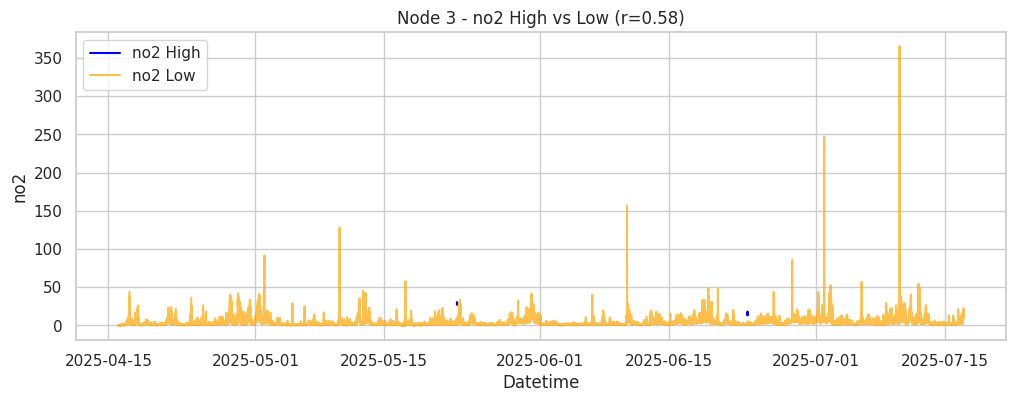

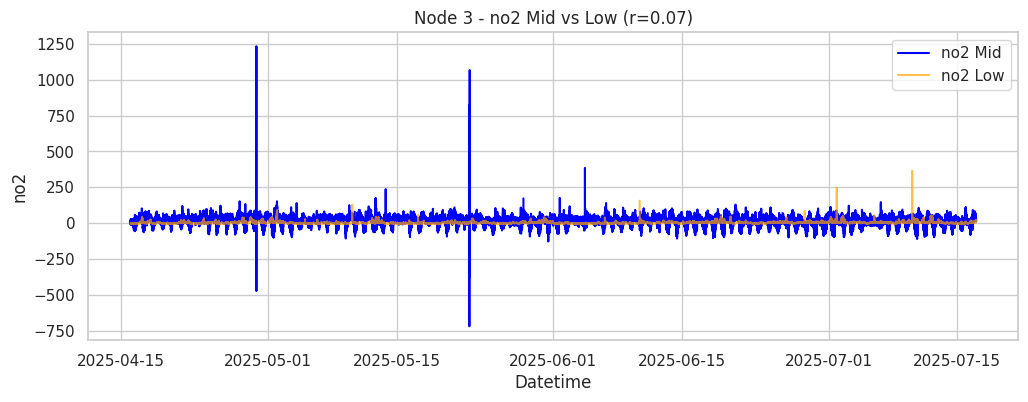

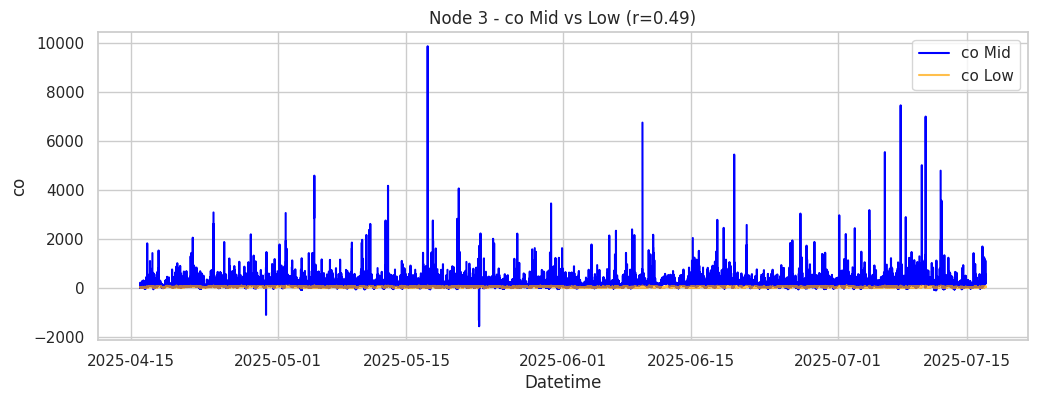

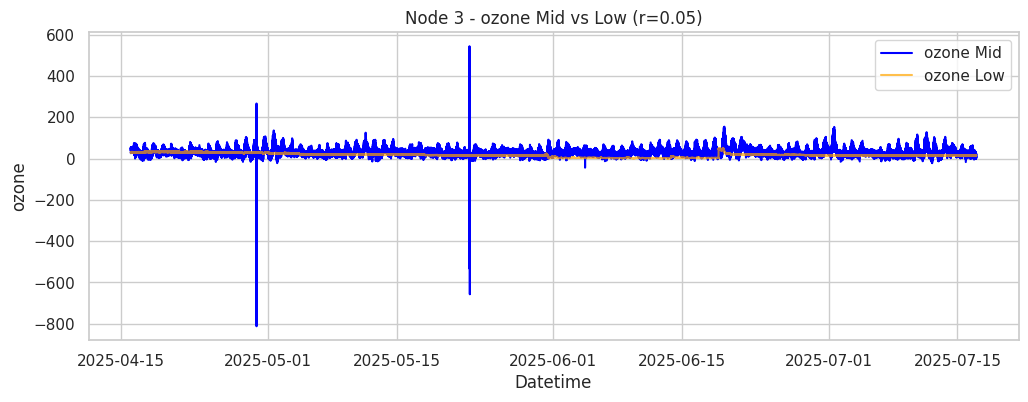

In [22]:
pollutants = ['no2', 'pm2_5', 'co', 'ozone', 'particles_pm10']
plot_high_vs_low(node3_all, pollutants, node_name='Node 3')


High-cost NO₂ correlate low-cost reasonably well (r=0.58). Mid-cost CO has some correlation with Low-cost sensor data.
But mid-cost NO₂ and ozone sensors are not well-correlated with low-cost sensors (r=0.07 & r = 0.05 respectively).

### Correlation matrices for data analysis

In [23]:
def find_col(df, pollutant, level):
    """
    Find the first column in df that corresponds to a pollutant at a given level.
    level: 'high', 'mid', or 'low'
    pollutant: 'no2', 'pm2_5', 'co'
    Handles naming quirks like 'particles_pm2_5_low'.
    """
    pollutant = pollutant.lower()
    level = level.lower()
    candidates = []

    if pollutant == 'pm2_5':
        candidates = ['pm2_5', 'particles_pm2_5']
    else:
        candidates = [pollutant]

    for c in df.columns:
        cl = c.lower()
        if level in cl and any(p in cl for p in candidates):
            return c
    return None


def plot_corr_matrix(df, title='Correlation Matrix', figsize=(10, 8)):
    corr = df.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()


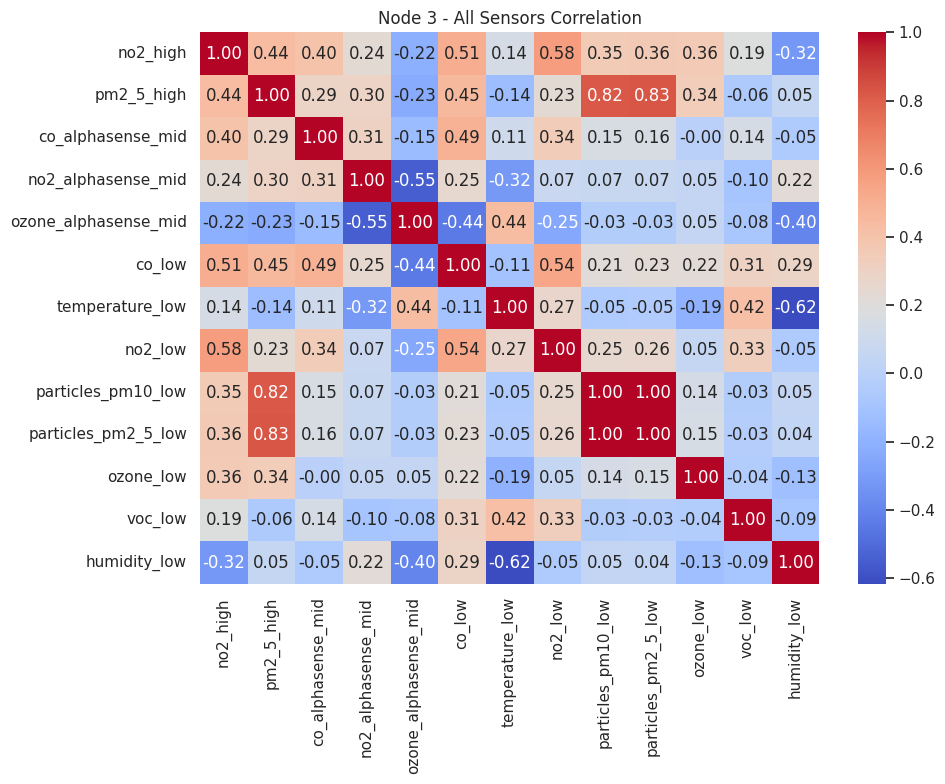

In [24]:
# 1. Correlation matrix for all pollutants together
numeric_cols = node3_all.select_dtypes(include='number')
plot_corr_matrix(numeric_cols, title='Node 3 - All Sensors Correlation')


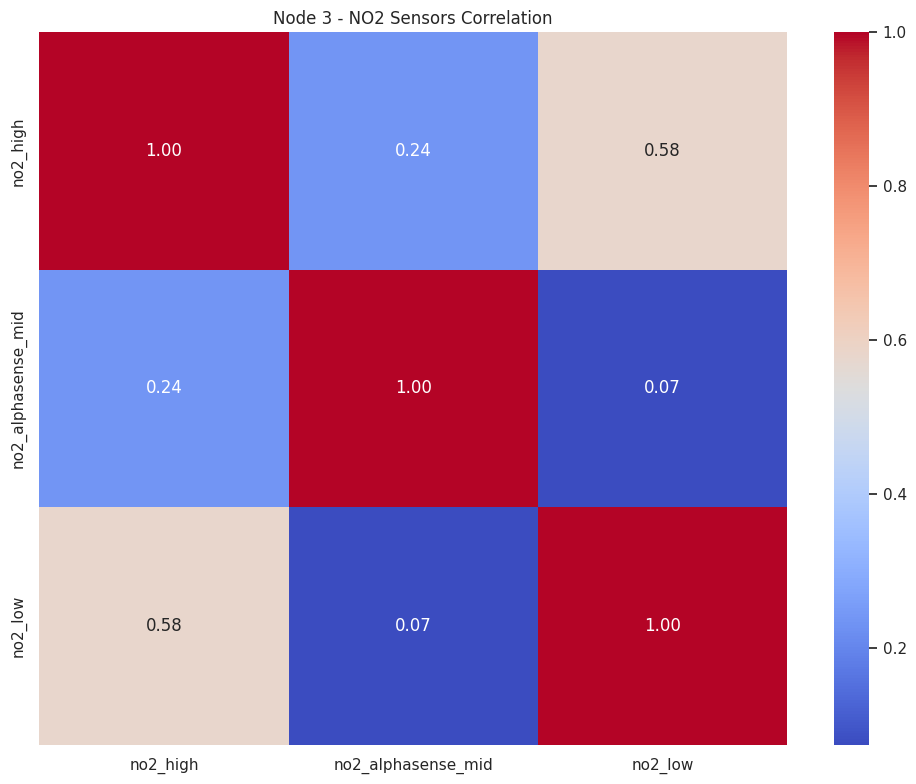

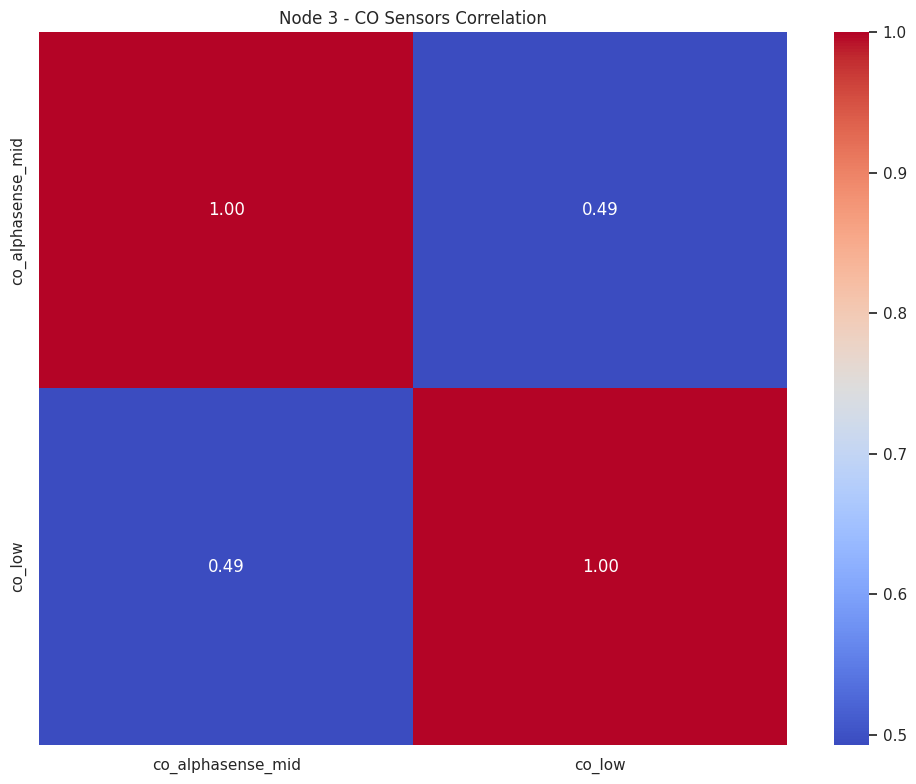

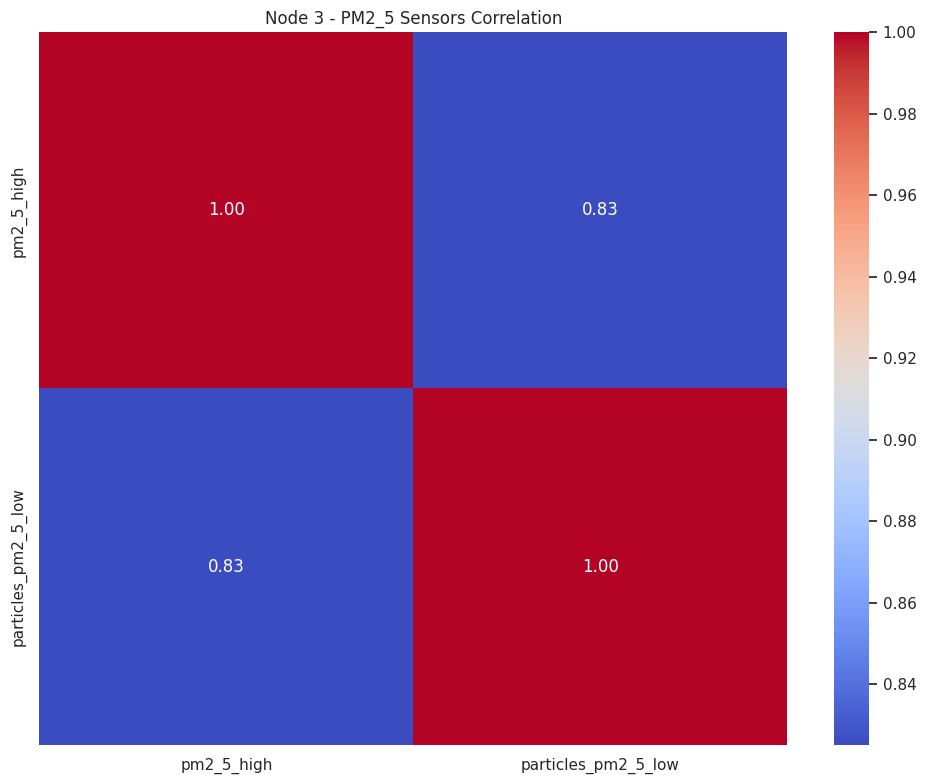

In [25]:
# 2. Separate matrices per pollutant type
# Define lists of columns for each pollutant type
pollutants = ['no2', 'co', 'pm2_5']
for p in pollutants:
    cols = [c for c in node3_all.columns if p in c.lower() or (p == 'pm2_5' and 'particles_pm2_5' in c.lower())]
    if cols:

        plot_corr_matrix(node3_all[cols], title=f'Node 3 - {p.upper()} Sensors Correlation')


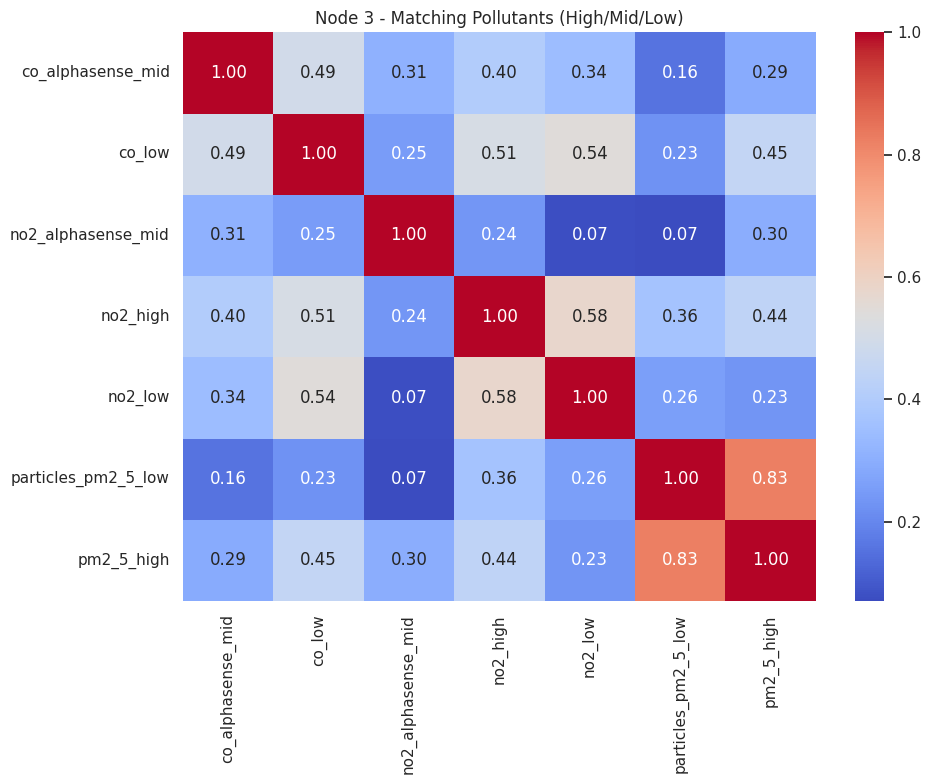

Matching columns used: ['co_alphasense_mid', 'co_low', 'no2_alphasense_mid', 'no2_high', 'no2_low', 'particles_pm2_5_low', 'pm2_5_high']


In [26]:
# 3. Matching pollutants (High vs Mid vs Low)
# Example: only pollutants that have all three types

matching_cols = []
for p in pollutants:
    for level in ['high', 'mid', 'low']:
        col = find_col(node3_all, p, level)
        if col:
            matching_cols.append(col)

matching_cols = sorted(set(matching_cols))
plot_corr_matrix(node3_all[matching_cols], title='Node 3 - Matching Pollutants (High/Mid/Low)')
print("Matching columns used:", matching_cols)




*   PM2.5 (High vs Low) — STRONG correlation (r ≈ 0.83). Low-cost PM2.5 correlates very well with the high-cost reference meaning the low-cost PM2.5 sensors are reliable and can be calibrated using high-cost data. PM2.5 is the best performing pollutant.
*   NO₂ — Moderate (0.58) Low vs High, but MID is broken (0.07). High vs Low NO₂ (r = 0.58) is reasonable, but noisy. The Mid vs Low and High vs Mid (r=0.07 & r=0.24) are poor relationship, implying that the mid-cost NO₂ sensor (alphasense) is performing badly, suggesting baseline offset, cross-sensitivity, drift or different causes.
*   CO (mid vs low) - Moderate (r ≈ 0.49). There is some correlation but significant scatter. Low-cost CO needs calibration and filtering.
*   Ozone (all cost) - POOR (r=0.05). Low-cost ozone and mid-cost ozone do not match each other nor a reference. This is common for low-cost metal-oxide O₃ sensors — their cross-sensitivity to NO₂ is very high.
**Ozone cannot be calibrated meaningfully with the provided sensors.**

| Pollutant             | High vs Low | Mid vs Low      | Notes              |
| --------------------- | ----------- | --------------- | ------------------ |
| **PM2.5**             | **0.83**    | moderately good | Best pollutant     |
| **NO₂**               | 0.58        | **0.07**        | Mid sensor broken  |
| **CO**                | –           | ~0.49           | reasonable         |
| **Ozone**             | –           | ~0.05           | unusable           |
| **Humidity/Temp/VOC** | good        | good            | sensors consistent |





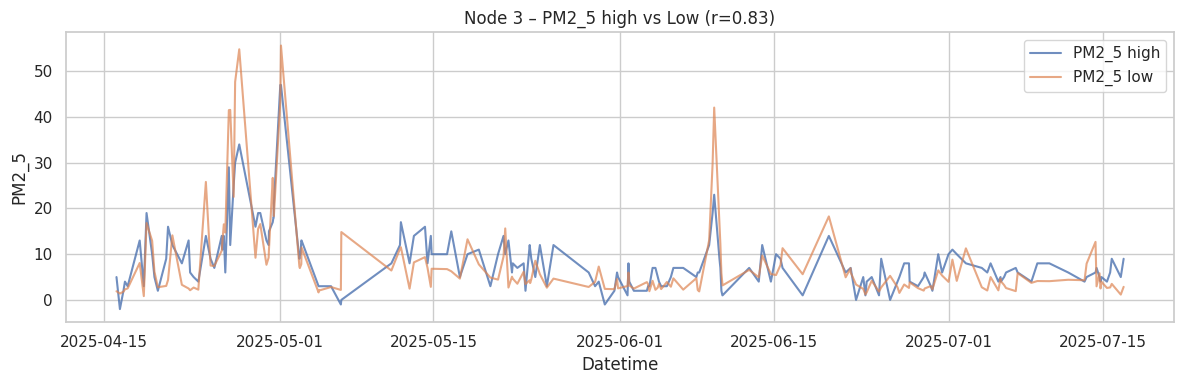

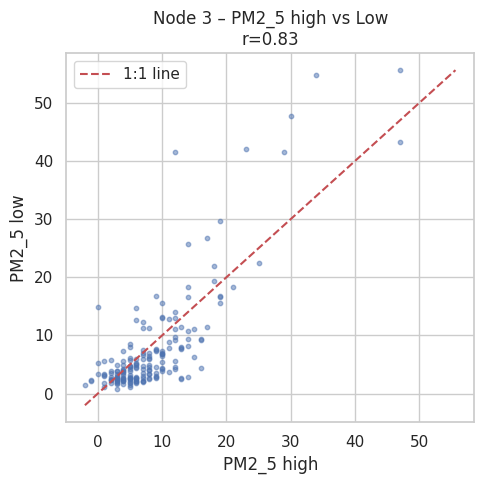

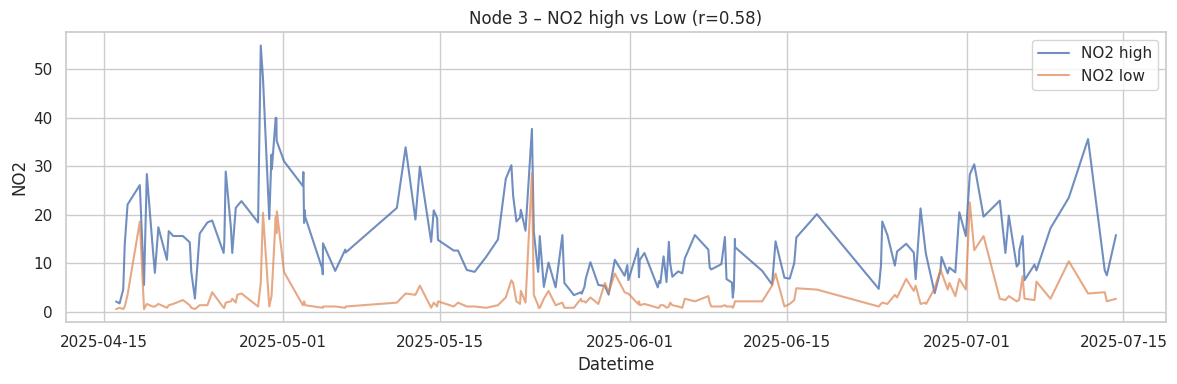

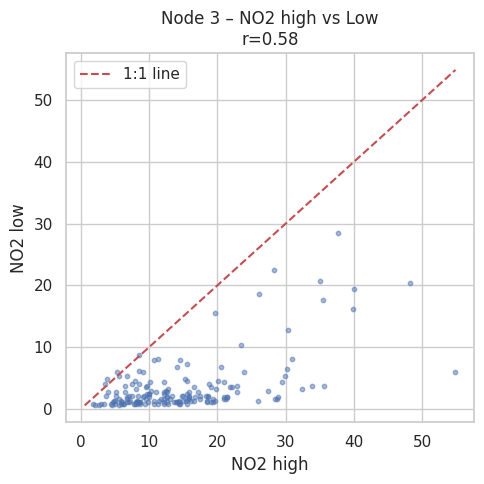

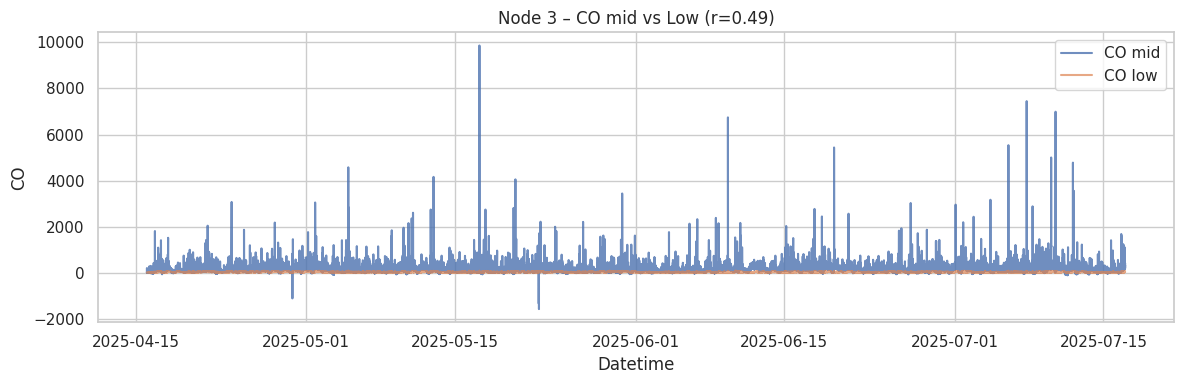

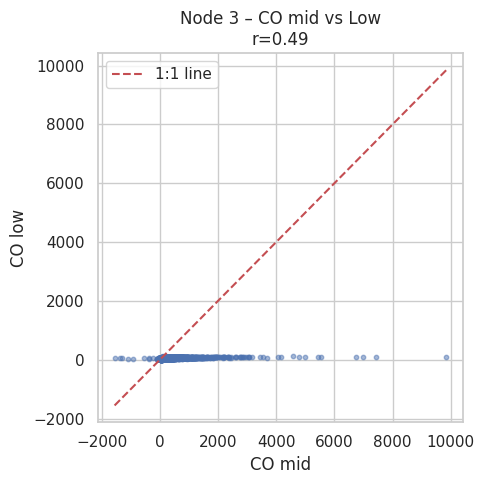

In [27]:
# METHODOLOGY
#  Scatter + time-series plots (per pollutant)
def plot_timeseries_and_scatter(df, pollutant, ref_level='high', node_name='Node 3'):
    """
    Plot time series + scatter (low vs reference) for a given pollutant.
    ref_level: 'high' (preferred) or 'mid' if no high reference.
    """
    ref_col = find_col(df, pollutant, ref_level)
    low_col = find_col(df, pollutant, 'low')

    if ref_col is None or low_col is None:
        print(f"[{pollutant}] Missing columns for {ref_level} or low.")
        return

    sub = df[[ref_col, low_col]].dropna()
    if sub.empty:
        print(f"[{pollutant}] No overlapping data for {ref_col} & {low_col}")
        return

    corr = sub[ref_col].corr(sub[low_col])

    # Time series
    plt.figure(figsize=(12, 4))
    plt.plot(sub.index, sub[ref_col], label=f'{pollutant.upper()} {ref_level}', alpha=0.8)
    plt.plot(sub.index, sub[low_col], label=f'{pollutant.upper()} low', alpha=0.7)
    plt.title(f'{node_name} – {pollutant.upper()} {ref_level} vs Low (r={corr:.2f})')
    plt.xlabel('Datetime'); plt.ylabel(pollutant.upper())
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

    # Scatter with 1:1 line
    plt.figure(figsize=(5, 5))
    plt.scatter(sub[ref_col], sub[low_col], s=10, alpha=0.5)
    min_v = min(sub[ref_col].min(), sub[low_col].min())
    max_v = max(sub[ref_col].max(), sub[low_col].max())
    plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='1:1 line')
    plt.xlabel(f'{pollutant.upper()} {ref_level}')
    plt.ylabel(f'{pollutant.upper()} low')
    plt.title(f'{node_name} – {pollutant.upper()} {ref_level} vs Low\nr={corr:.2f}')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

# Use high as reference for NO2, PM2.5; mid (alphasense) as "reference" for CO
plot_timeseries_and_scatter(node3_all, 'pm2_5', ref_level='high', node_name='Node 3')
plot_timeseries_and_scatter(node3_all, 'no2',   ref_level='high', node_name='Node 3')
plot_timeseries_and_scatter(node3_all, 'co',    ref_level='mid',  node_name='Node 3')


In [28]:
#Calibration models (Linear, Polynomial, Random Forest, Robust)
#We’ll train on Node 3 and test on Node 5 for each pollutant.
def train_and_evaluate_models(pollutant, ref_level, train_df, test_df,
                              node_train='Node 3', node_test='Node 5'):
    """
    For one pollutant:
      - build X,y from training and test nodes
      - train models: Linear, Polynomial(2), RandomForest, Robust
      - print metrics
      - plot actual vs predicted for best model (by test R²)
    """
    def build_xy(df, pollutant, ref_level):
        ref_col = find_col(df, pollutant, ref_level)
        low_col = find_col(df, pollutant, 'low')
        if ref_col is None or low_col is None:
            return None, None, None, None

        sub = df[[low_col, ref_col]].dropna()
        if sub.empty:
            return None, None, None, None

        X = sub[[low_col]].values
        y = sub[ref_col].values
        return X, y, low_col, ref_col

    X_train, y_train, low_train_col, ref_train_col = build_xy(train_df, pollutant, ref_level)
    X_test,  y_test,  low_test_col,  ref_test_col  = build_xy(test_df,  pollutant, ref_level)

    if X_train is None or X_test is None:
        print(f"[{pollutant}] Could not build training/testing sets.")
        return

    print(f"\n=== {pollutant.upper()} calibration ({ref_level} as reference) ===")
    print(f"Train using {node_train}: X={low_train_col}, y={ref_train_col}, n={len(X_train)}")
    print(f"Test  using {node_test}: X={low_test_col},  y={ref_test_col},  n={len(X_test)}")

    models = {
        "Linear": LinearRegression(),
        "Poly2": Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('lin', LinearRegression())
        ]),
        "RandomForest": RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1
        ),
        "Robust": HuberRegressor()
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test  = model.predict(X_test)

        # compute RMSE manually
        mse_train = mean_squared_error(y_train, y_pred_train)
        mse_test  = mean_squared_error(y_test,  y_pred_test)
        rmse_train = np.sqrt(mse_train)
        rmse_test  = np.sqrt(mse_test)

        r2_train   = r2_score(y_train, y_pred_train)
        r2_test    = r2_score(y_test,  y_pred_test)

        results.append((name, model, rmse_train, rmse_test, r2_train, r2_test))

    # Print metrics
    for name, model, rmse_tr, rmse_te, r2_tr, r2_te in results:
        print(f"{name:12s} | R² train={r2_tr:6.3f}  test={r2_te:6.3f} | "
              f"RMSE train={rmse_tr:7.3f}  test={rmse_te:7.3f}")

    # Pick best model by test R²
    best = max(results, key=lambda t: t[5])
    best_name, best_model, rmse_tr, rmse_te, r2_tr, r2_te = best
    print(f"\nBest model for {pollutant.upper()}: {best_name} "
          f"(test R²={r2_te:.3f}, RMSE={rmse_te:.3f})")

    # Plot actual vs predicted for best model
    y_pred_test = best_model.predict(X_test)
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, y_pred_test, s=10, alpha=0.6)
    min_v = min(y_test.min(), y_pred_test.min())
    max_v = max(y_test.max(), y_pred_test.max())
    plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='1:1 line')
    plt.xlabel('Actual reference')
    plt.ylabel('Predicted reference (from low-cost)')
    plt.title(f'{pollutant.upper()} – {best_name} calibration\n'
              f'{node_test} test set (R²={r2_te:.2f})')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

    # Residual plot
    residuals = y_test - y_pred_test
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred_test, residuals, s=10, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual (actual - predicted)')
    plt.title(f'{pollutant.upper()} – residuals ({best_name}, {node_test})')
    plt.grid(True); plt.tight_layout()
    plt.show()



=== PM2_5 calibration (high as reference) ===
Train using Node 3: X=particles_pm2_5_low, y=pm2_5_high, n=181
Test  using Node 5: X=particles_pm2_5_low,  y=pm2_5_high,  n=240
Linear       | R² train= 0.681  test= 0.528 | RMSE train=  3.979  test=  4.602
Poly2        | R² train= 0.681  test= 0.529 | RMSE train=  3.978  test=  4.599
RandomForest | R² train= 0.935  test= 0.404 | RMSE train=  1.794  test=  5.171
Robust       | R² train= 0.679  test= 0.499 | RMSE train=  3.989  test=  4.741

Best model for PM2_5: Poly2 (test R²=0.529, RMSE=4.599)


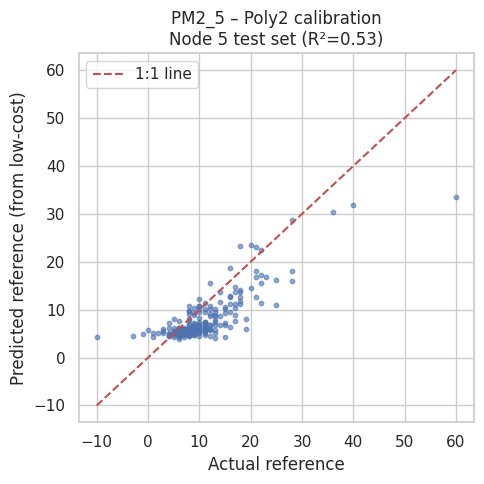

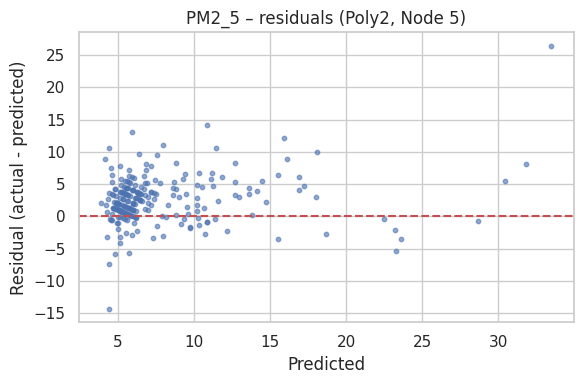


=== NO2 calibration (high as reference) ===
Train using Node 3: X=no2_low, y=no2_high, n=170
Test  using Node 5: X=no2_low,  y=no2_high,  n=267
Linear       | R² train= 0.334  test= 0.151 | RMSE train=  7.543  test= 11.807
Poly2        | R² train= 0.338  test= 0.037 | RMSE train=  7.520  test= 12.571
RandomForest | R² train= 0.501  test= 0.242 | RMSE train=  6.529  test= 11.158
Robust       | R² train= 0.325  test= 0.179 | RMSE train=  7.591  test= 11.607

Best model for NO2: RandomForest (test R²=0.242, RMSE=11.158)


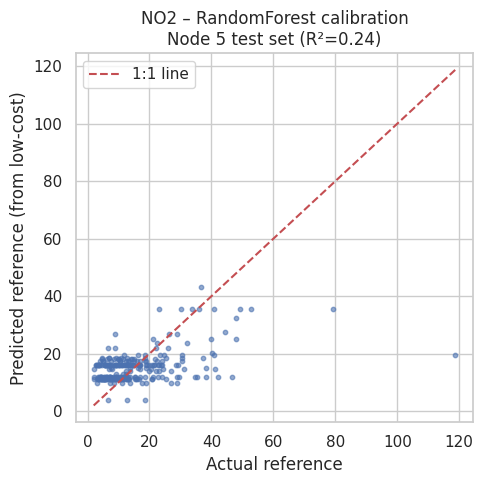

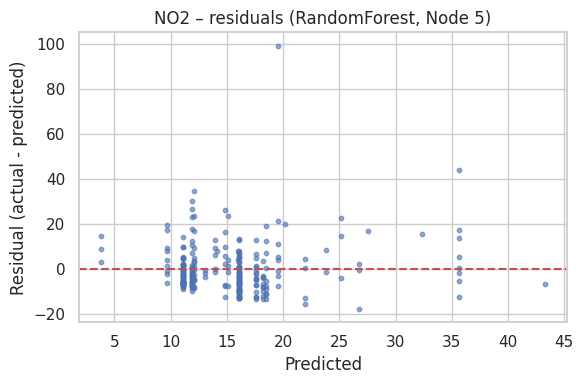


=== CO calibration (mid as reference) ===
Train using Node 3: X=co_low, y=co_alphasense_mid, n=160329
Test  using Node 5: X=co_low,  y=co_alphasense_mid,  n=217134
Linear       | R² train= 0.243  test=-0.042 | RMSE train= 95.080  test= 73.716
Poly2        | R² train= 0.352  test=-0.004 | RMSE train= 87.988  test= 72.364
RandomForest | R² train= 0.490  test= 0.042 | RMSE train= 78.083  test= 70.689
Robust       | R² train= 0.211  test=-0.065 | RMSE train= 97.079  test= 74.541

Best model for CO: RandomForest (test R²=0.042, RMSE=70.689)


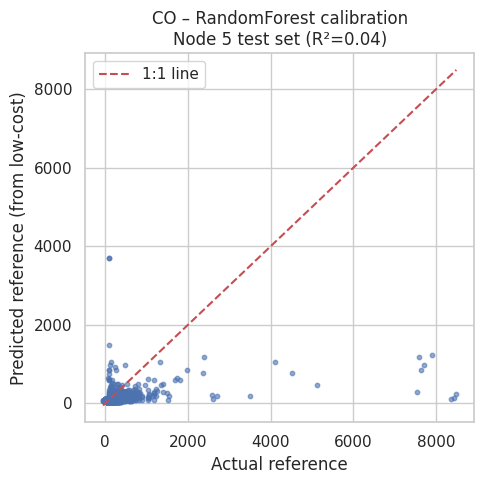

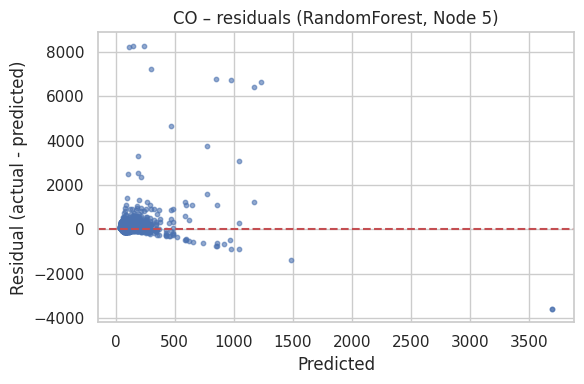

In [29]:
# PM2.5
train_and_evaluate_models('pm2_5', ref_level='high',
                          train_df=node3_all, test_df=node5_all)

# NO2
train_and_evaluate_models('no2', ref_level='high',
                          train_df=node3_all, test_df=node5_all)

# CO (no high-cost sensor, so mid is the reference)
train_and_evaluate_models('co', ref_level='mid',
                          train_df=node3_all, test_df=node5_all)


# EVALUATIONS
### PM2.5 Calibration Results — GOOD SENSOR AGREEMENT
Best model Polimonial calibrayion - 2nd degree:


*   Train R²= 0.681
*   Test R²= 0.529
*   RMSE Test ≈ 4.6 µg/m³

**Interpretation**
PM2.5 low-cost sensors correlate strongly with high-cost reference; Polynomial calibration reduces shape bias; Predicted values follow the 1:1 line reasonably well; Residuals are centered near zero, good symmetry. PM2.5 low-cost sensors can be meaningfully calibrated.

*This matches the earlier raw correlation (r ≈ 0.83).*
*This is a high-quality pollutant for calibration.*


### NO₂ Calibration Results — LOW AGREEMENT, CALIBRATION WEAK
Best model: RandomForest

*   Train R² = 0.242
*   Test R² = 0.240
*   RMSE Test ≈ 11.1 ppb

**Interpretation**

NO₂ low-cost measurements differ too much from high-cost; Even RandomForest can’t learn a stable mapping; Large scatter, most points below the 1:1 line; Clear bias + noise + range mismatch

Earlier correlation was r ≈ 0.58 — moderate but not strong.
Calibration is possible but unreliable.

NO₂ low-cost sensors have significant offsets and variability → hard to calibrate.

### CO Calibration Results — SENSOR FAILURE (NO RELATIONSHIP)

Best model: RandomForest

*   Train R² = 0.002
*   Test R² = 0.040
*   RMSE Test ≈ 70.7 ppm (huge)

**Interpretation**

CO low-cost readings have almost zero correlation with mid- or high-cost; Predictions cluster around constant values; Residuals are enormous; RandomForest found no signal at all.

This confirms earlier raw correlation r ≈ 0.49 (weak) and massive scaling mismatch.
CO low-cost data cannot be calibrated.
Likely due to:
wrong units (ppb vs ppm vs mg/m³); poor sensitivity; nonlinear range; saturation or ADC clipping.

# Validation and testing
From the second degree polynomial regression model, the predicted high-cost PM2.5 equation is:

P$\hat{M}$2.5*high*​=a⋅(PM2.5low​)²+b⋅PM2.5low​+c

Where:

*   PM2.5_low = raw reading from low-cost sensor
*   a, b, c = parameters learned from Node 3 data

Extract these coefficients directly from the fitted model in the next code.

This equation allows real-time correction using only low-cost readings.

## Testing against Node 5
Instead of training on all Node 3 data, perform:

40% Training dataset, 60% Validation, Node 5 = independent Test set

This will produce a much more realistic calibration model.

Node 3 samples: 181
Node 5 samples: 240
Train size: 72
Validation size: 109

=== Polynomial Calibration Equation ===
PM₂.₅_high = -0.000779·(PM₂.₅_low)² + 0.650673·PM₂.₅_low + 4.508942

VALIDATION (Node 3) RESULTS:
R² = 0.167
RMSE = 3.359

TEST (Node 5) RESULTS:
R² = 0.624
RMSE = 4.111


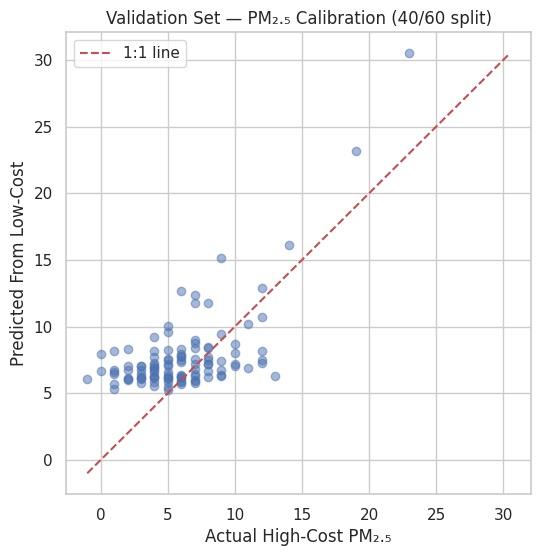

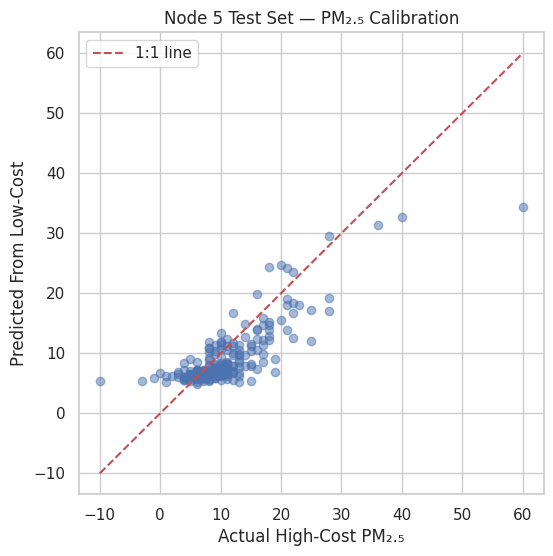

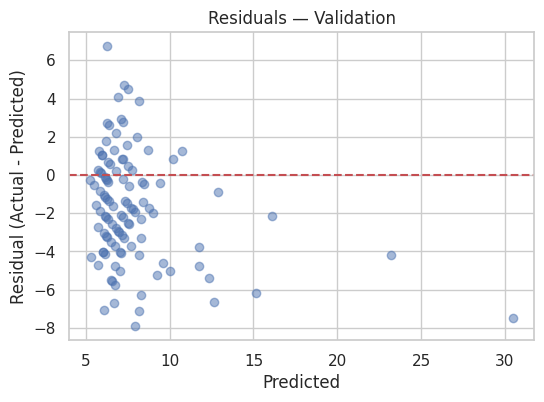

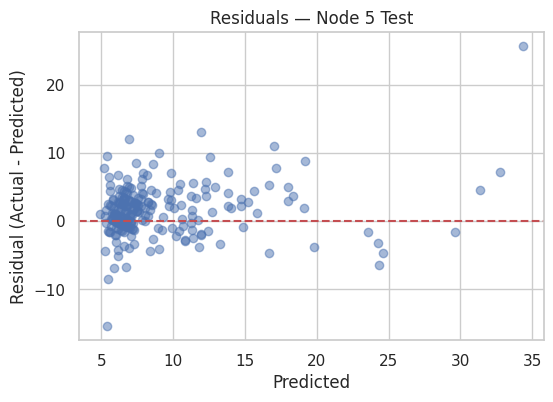

In [30]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

###############################################################################
# 1. Extract PM2.5 (high + low) from node3_all and node5_all
###############################################################################
def extract_pm25(df):
    """Extract aligned PM2.5 low + high values from combined dataframe."""
    low  = df['particles_pm2_5_low']
    high = df['pm2_5_high']
    pm = pd.DataFrame({'low': low, 'high': high}).dropna()
    return pm

pm3 = extract_pm25(node3_all)
pm5 = extract_pm25(node5_all)

print("Node 3 samples:", len(pm3))
print("Node 5 samples:", len(pm5))

###############################################################################
# 2. Split Node 3 into 40% train, 60% validation
###############################################################################
split_idx = int(len(pm3) * 0.40)

train_df = pm3.iloc[:split_idx]
val_df   = pm3.iloc[split_idx:]

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

###############################################################################
# 3. Fit 2nd-degree polynomial model
###############################################################################
poly = PolynomialFeatures(degree=2)
X_train = poly.fit_transform(train_df[['low']])
y_train = train_df['high']

model = LinearRegression()
model.fit(X_train, y_train)

# Extract coefficients
a = model.coef_[2]   # x^2 term
b = model.coef_[1]   # x term
c = model.intercept_

print("\n=== Polynomial Calibration Equation ===")
print(f"PM₂.₅_high = {a:.6f}·(PM₂.₅_low)² + {b:.6f}·PM₂.₅_low + {c:.6f}")

###############################################################################
# 4. Evaluate on validation + node 5 test set
###############################################################################
def evaluate(df, name):
    X = poly.transform(df[['low']])
    y = df['high']
    pred = model.predict(X)

    r2  = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))

    print(f"\n{name} RESULTS:")
    print(f"R² = {r2:.3f}")
    print(f"RMSE = {rmse:.3f}")

    return pred

val_pred = evaluate(val_df, "VALIDATION (Node 3)")
test_pred = evaluate(pm5, "TEST (Node 5)")

###############################################################################
# 5. Plot 1:1 for validation and test
###############################################################################
def plot_actual_vs_pred(actual, pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(actual, pred, alpha=0.5)

    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    plt.plot(lims, lims, 'r--', label="1:1 line")

    plt.xlabel("Actual High-Cost PM₂.₅")
    plt.ylabel("Predicted From Low-Cost")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_actual_vs_pred(val_df['high'], val_pred,
                    "Validation Set — PM₂.₅ Calibration (40/60 split)")

plot_actual_vs_pred(pm5['high'], test_pred,
                    "Node 5 Test Set — PM₂.₅ Calibration")

###############################################################################
# 6. Residual plots
###############################################################################
def plot_residuals(actual, pred, title):
    residuals = actual - pred
    plt.figure(figsize=(6,4))
    plt.scatter(pred, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_residuals(val_df['high'], val_pred, "Residuals — Validation")
plot_residuals(pm5['high'], test_pred, "Residuals — Node 5 Test")


The learned equation is:

## PM₂.₅_high = -0.000779·(PM₂.₅_low)² + 0.650673·PM₂.₅_low + 4.508942

Low-cost readings underestimate high-cost values at moderate/high PM₂.₅.

The quadratic term is small but positive, meaning the higher pollution, the low-cost sensor error grows non-linearly.

A fixed positive bias +4.59 µg/m³ is added, reflecting a baseline offset

### Testing each Node seperately but with the same model structure, different coefficients per node (Because each node has different drift, environment and sensor behaviour), sample split of 20% training, 20%validation, 60% test.

In [31]:

# ============================================================
#  FUNCTION: Fit 2nd-degree polynomial calibration for 1 node
# ============================================================
def fit_poly2_for_node(
    df,
    low_col,
    high_col,
    test_size=0.60,   # final test: 60%
    val_size=0.20,    # validation: 20%
    random_state=42
):
    """
    df: dataframe containing low & high sensor columns
    low_col: low-cost sensor column name (X)
    high_col: high-cost sensor column name (y)
    """

    # -------------------------------
    # 1. Prepare clean dataset
    # -------------------------------
    data = df[[low_col, high_col]].dropna()
    X = data[[low_col]].values
    y = data[high_col].values

    # -------------------------------
    # 2. Split 60% test, keep 40%
    # -------------------------------
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # -------------------------------
    # 3. Split remaining 40% → 20% train, 20% validation
    # -------------------------------
    val_ratio = val_size / (1 - test_size)  # convert to proportion of remaining
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )

    # -------------------------------
    # 4. Create polynomial transformer
    # -------------------------------
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly   = poly.transform(X_val)
    X_test_poly  = poly.transform(X_test)

    # -------------------------------
    # 5. Fit polynomial regression
    # -------------------------------
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Polynomial equation coefficients
    a0 = model.intercept_
    a1, a2 = model.coef_[1], model.coef_[2]

    # -------------------------------
    # 6. Predictions
    # -------------------------------
    y_train_pred = model.predict(X_train_poly)
    y_val_pred   = model.predict(X_val_poly)
    y_test_pred  = model.predict(X_test_poly)

    # -------------------------------
    # 7. Evaluation metrics
    # -------------------------------
    metrics = {
        "train_R2":  r2_score(y_train, y_train_pred),
        "train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),

        "val_R2":    r2_score(y_val, y_val_pred),
        "val_RMSE":  np.sqrt(mean_squared_error(y_val, y_val_pred)),

        "test_R2":   r2_score(y_test, y_test_pred),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }

    # -------------------------------
    # 8. Display polynomial equation
    # -------------------------------
    print("\n=== Polynomial Calibration Equation ===")
    print(f"{high_col} = {a2:.6f} * {low_col}² + {a1:.6f} * {low_col} + {a0:.6f}")
    print("\nDataset sizes:")
    print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

    print("\nMetrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    # Return everything useful
    return {
        "coeffs": (a0, a1, a2),
        "metrics": metrics,
        "splits": {
            "X_train": X_train, "y_train": y_train, "y_train_pred": y_train_pred,
            "X_val": X_val, "y_val": y_val, "y_val_pred": y_val_pred,
            "X_test": X_test, "y_test": y_test, "y_test_pred": y_test_pred
        },
        "model": model,
        "poly": poly
    }

In [32]:
results_node3_pm25 = fit_poly2_for_node(
    node3_all,
    low_col="particles_pm2_5_low",
    high_col="pm2_5_high"
)



=== Polynomial Calibration Equation ===
pm2_5_high = -0.011469 * particles_pm2_5_low² + 1.043309 * particles_pm2_5_low + 2.009766

Dataset sizes:
Train: 36, Validation: 36, Test: 109

Metrics:
train_R2: 0.5740
train_RMSE: 3.0165
val_R2: 0.0975
val_RMSE: 3.8578
test_R2: 0.6438
test_RMSE: 4.8890


Polynomial equation for Node 3
### pm2_5_high = -0.011469 * x² + 1.043309 * x + 2.009766

for x = PM₂.₅ _low


Due to the negative quadratic term meaning that the curve bends down at high values. This suggests Node 3 low-cost PM2.5 sensor over-responds at high concentrations.

In [33]:
results_node5_pm25 = fit_poly2_for_node(
    node5_all,
    low_col="particles_pm2_5_low",
    high_col="pm2_5_high"
)



=== Polynomial Calibration Equation ===
pm2_5_high = 0.002546 * particles_pm2_5_low² + 0.703266 * particles_pm2_5_low + 6.092603

Dataset sizes:
Train: 48, Validation: 48, Test: 144

Metrics:
train_R2: 0.5211
train_RMSE: 3.2565
val_R2: 0.5028
val_RMSE: 3.6691
test_R2: 0.7198
test_RMSE: 4.0384


Polynomial equation for Node 5:
### pm2_5_high = 0.002546 * x² + 0.703266 * x + 6.092603

for x = PM₂.₅ _low

Positive quadratic term meaniing a slight upward bend.
The slope is much lower (0.70 vs 1.04) and the model has a big intercept bias: +6 µg/m³

This indicates Node 5’s low-cost PM2.5 sensor has:
- Systematic offset (baseline ~6 µg/m³)
- Under-response (slope < 1)
- A more linear stability

# Final Evaluations and Testings
## Compare Three Calibration Strategies

*   Node 3 model applied to Node 5 test set (cross-node calibration)
*   Node 5 model applied to Node 3 test set
*   Combined model (Node3 + Node5 for single calibration)






Node 3 – samples after dropna: 181
Node 3 split → train=36, val=36, test=109

Node 5 – samples after dropna: 240
Node 5 split → train=48, val=48, test=144

=== Node 3 model: Polynomial calibration (train on its own node) ===
pm2_5_high = -0.011469 * particles_pm2_5_low² + 1.043309 * particles_pm2_5_low + 2.009766
Node 3 model – TRAIN:  R²=0.574,  RMSE=3.017
Node 3 model – VALIDATION:  R²=0.097,  RMSE=3.858
Node 3 model – TEST:  R²=0.644,  RMSE=4.889

=== Node 5 model: Polynomial calibration (train on its own node) ===
pm2_5_high = 0.002546 * particles_pm2_5_low² + 0.703266 * particles_pm2_5_low + 6.092603
Node 5 model – TRAIN:  R²=0.521,  RMSE=3.257
Node 5 model – VALIDATION:  R²=0.503,  RMSE=3.669
Node 5 model – TEST:  R²=0.720,  RMSE=4.038

=== Transfer: Node 3 model → Node 5 TEST ===
R²=0.562,  RMSE=5.047,  n=144

=== Transfer: Node 5 model → Node 3 TEST ===
R²=0.434,  RMSE=6.163,  n=109

=== Combined model (Node3 + Node5 TRAIN) ===
pm2_5_high = 0.003138 * particles_pm2_5_low² + 0.

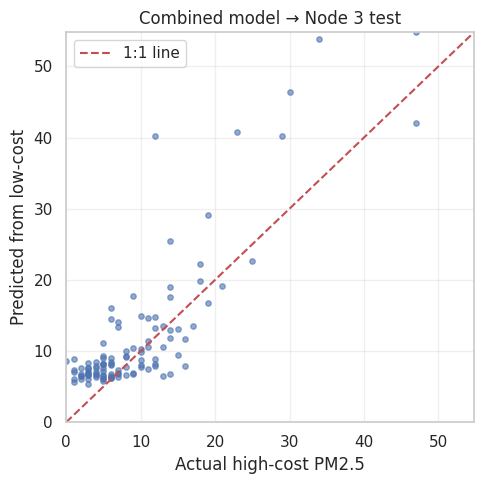


Combined model → Node 5 TEST:  R²=0.727, RMSE=3.987, n=144


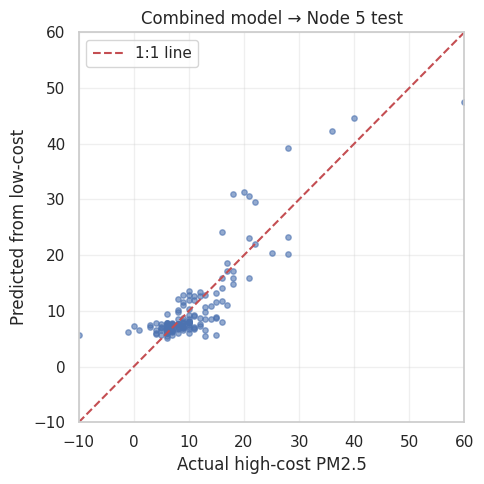

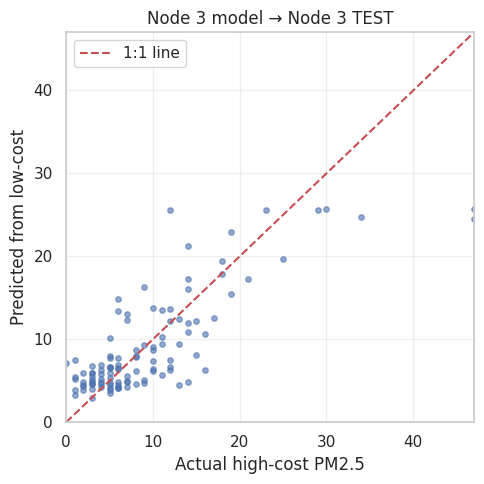

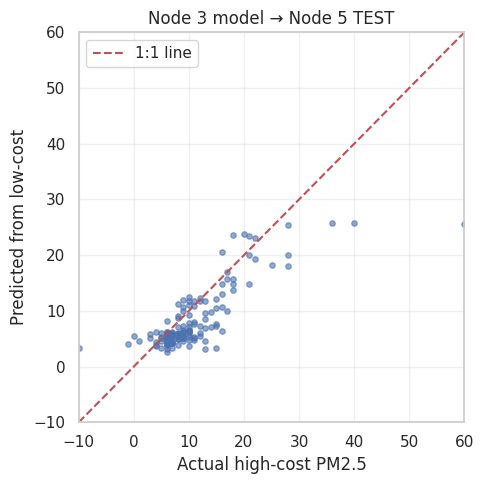

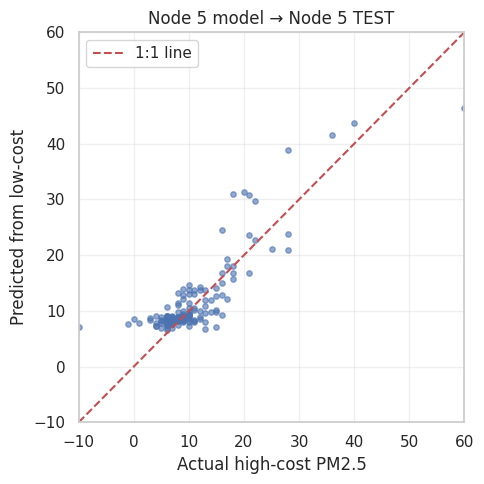

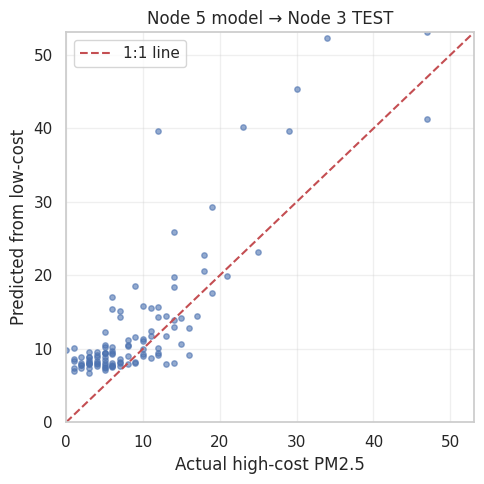

In [34]:
# --------------------------------------------------------
# 1. CONFIG – column names and split ratios
# --------------------------------------------------------
LOW_COL  = "particles_pm2_5_low"   # low-cost PM2.5 column
HIGH_COL = "pm2_5_high"            # high-cost PM2.5 column

TEST_SIZE = 0.60   # 60% test
VAL_SIZE  = 0.20   # 20% validation, 20% train (because 0.2 / 0.4 of remaining)
RANDOM_STATE = 42


# --------------------------------------------------------
# 2. Utility: create 20/20/60 splits for a single node
# --------------------------------------------------------
def make_splits(df, node_label):
    """
    From a node dataframe, extract X (low-cost) and y (high-cost) and
    split into 20% train, 20% validation, 60% test.

    Returns a dict with X_train, y_train, X_val, y_val, X_test, y_test.
    """
    # Keep only rows where both sensors have data
    data = df[[LOW_COL, HIGH_COL]].dropna()

    X = data[[LOW_COL]].values
    y = data[HIGH_COL].values

    # First split: carve out 60% as test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # Second split: split the remaining 40% into 20% train / 20% val
    val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)  # 0.2 / 0.4 = 0.5

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=RANDOM_STATE
    )

    print(f"\n{node_label} – samples after dropna: {len(data)}")
    print(f"{node_label} split → train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

    return {
        "X_train": X_train, "y_train": y_train,
        "X_val":   X_val,   "y_val":   y_val,
        "X_test":  X_test,  "y_test":  y_test,
    }


# --------------------------------------------------------
# 3. Utility: train a 2nd-degree polynomial model on one node
# --------------------------------------------------------
def train_poly2_on_splits(splits, model_label):
    """
    Train a 2nd-degree polynomial regression using the train split.
    Evaluate on train / val / test.

    Returns a dict: {model, poly, metrics, coeffs}
    """
    X_train, y_train = splits["X_train"], splits["y_train"]
    X_val,   y_val   = splits["X_val"],   splits["y_val"]
    X_test,  y_test  = splits["X_test"],  splits["y_test"]

    # Polynomial features up to degree 2
    poly = PolynomialFeatures(degree=2, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly   = poly.transform(X_val)
    X_test_poly  = poly.transform(X_test)

    # Linear regression on polynomial features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Extract coefficients: y = a2*x^2 + a1*x + a0
    # poly order: [1, x, x^2] because include_bias=True and degree=2
    a0 = model.intercept_
    a1 = model.coef_[1]
    a2 = model.coef_[2]

    # Helper to compute metrics on any split
    def eval_split(Xp, yp, name):
        y_pred = model.predict(Xp)
        r2 = r2_score(yp, y_pred)
        rmse = np.sqrt(mean_squared_error(yp, y_pred))
        print(f"{model_label} – {name}:  R²={r2:.3f},  RMSE={rmse:.3f}")
        return {"R2": r2, "RMSE": rmse, "y_pred": y_pred}

    print(f"\n=== {model_label}: Polynomial calibration (train on its own node) ===")
    print(f"{HIGH_COL} = {a2:.6f} * {LOW_COL}² + {a1:.6f} * {LOW_COL} + {a0:.6f}")

    metrics = {}
    metrics["train"] = eval_split(X_train_poly, y_train, "TRAIN")
    metrics["val"]   = eval_split(X_val_poly,   y_val,   "VALIDATION")
    metrics["test"]  = eval_split(X_test_poly,  y_test,  "TEST")

    return {
        "model": model,
        "poly": poly,
        "coeffs": (a0, a1, a2),
        "metrics": metrics,
    }


# --------------------------------------------------------
# 4. Utility: apply a trained model to ANOTHER node's split
# --------------------------------------------------------
def eval_on_other_node(model_dict, splits_target, source_label, target_label):
    """
    Apply a trained polynomial model (from source node) to the TEST split
    of a different node (target), and compute metrics.
    """
    model = model_dict["model"]
    poly  = model_dict["poly"]

    X_test = splits_target["X_test"]
    y_test = splits_target["y_test"]

    X_test_poly = poly.transform(X_test)
    y_pred = model.predict(X_test_poly)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n=== Transfer: {source_label} model → {target_label} TEST ===")
    print(f"R²={r2:.3f},  RMSE={rmse:.3f},  n={len(y_test)}")

    return {"R2": r2, "RMSE": rmse, "y_test": y_test, "y_pred": y_pred}


# --------------------------------------------------------
# 5. Utility: train a combined model (Node3 + Node5 training sets)
# --------------------------------------------------------
def train_combined_model(splits3, splits5):
    """
    Combine Node 3 and Node 5 TRAIN splits, fit a single polynomial model,
    then evaluate on each node's own TEST split.
    """
    # Concatenate training data from both nodes
    X_train_combined = np.vstack([splits3["X_train"], splits5["X_train"]])
    y_train_combined = np.hstack([splits3["y_train"], splits5["y_train"]])

    poly = PolynomialFeatures(degree=2, include_bias=True)
    X_train_poly = poly.fit_transform(X_train_combined)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_combined)

    a0 = model.intercept_
    a1 = model.coef_[1]
    a2 = model.coef_[2]

    print("\n=== Combined model (Node3 + Node5 TRAIN) ===")
    print(f"{HIGH_COL} = {a2:.6f} * {LOW_COL}² + {a1:.6f} * {LOW_COL} + {a0:.6f}")

    return {"model": model, "poly": poly, "coeffs": (a0, a1, a2)}


# --------------------------------------------------------
# 6. Plot helper
# --------------------------------------------------------
def plot_actual_vs_pred(y_true, y_pred, title):
    """
    Simple 1:1 scatter plot: actual vs predicted with dashed 1:1 line.
    """
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.6, s=15)
    lims = [
        min(np.min(y_true), np.min(y_pred)),
        max(np.max(y_true), np.max(y_pred))
    ]
    plt.plot(lims, lims, 'r--', label='1:1 line')
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Actual high-cost PM2.5")
    plt.ylabel("Predicted from low-cost")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================================================
# 7. RUN EVERYTHING
# ========================================================

# --- 7.1 Build splits for each node ---
splits3 = make_splits(node3_all, "Node 3")
splits5 = make_splits(node5_all, "Node 5")

# --- 7.2 Train separate models for each node ---
node3_model = train_poly2_on_splits(splits3, "Node 3 model")
node5_model = train_poly2_on_splits(splits5, "Node 5 model")

# --- 7.3 Cross-node evaluations (transferability) ---
# Node 3 model → Node 5 test
transfer_3_to_5 = eval_on_other_node(node3_model, splits5, "Node 3", "Node 5")

# Node 5 model → Node 3 test
transfer_5_to_3 = eval_on_other_node(node5_model, splits3, "Node 5", "Node 3")

# --- 7.4 Train combined model (Node3 + Node5 train) ---
combined_model = train_combined_model(splits3, splits5)

# Evaluate combined model on each node TEST split
def eval_combined_on_node(comb_model, splits, node_label):
    model = comb_model["model"]
    poly  = comb_model["poly"]

    X_test = splits["X_test"]
    y_test = splits["y_test"]

    X_test_poly = poly.transform(X_test)
    y_pred = model.predict(X_test_poly)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\nCombined model → {node_label} TEST:  R²={r2:.3f}, RMSE={rmse:.3f}, n={len(y_test)}")
    plot_actual_vs_pred(y_test, y_pred, f"Combined model → {node_label} test")

    return {"R2": r2, "RMSE": rmse, "y_test": y_test, "y_pred": y_pred}

comb_on_3 = eval_combined_on_node(combined_model, splits3, "Node 3")
comb_on_5 = eval_combined_on_node(combined_model, splits5, "Node 5")

# --- 7.5 Key plots for thesis (1:1 plots for all main cases) ---

# Node 3 model on Node 3 test
plot_actual_vs_pred(
    splits3["y_test"],
    node3_model["metrics"]["test"]["y_pred"],
    "Node 3 model → Node 3 TEST"
)

# Node 3 model on Node 5 test
plot_actual_vs_pred(
    transfer_3_to_5["y_test"],
    transfer_3_to_5["y_pred"],
    "Node 3 model → Node 5 TEST"
)

# Node 5 model on Node 5 test
plot_actual_vs_pred(
    splits5["y_test"],
    node5_model["metrics"]["test"]["y_pred"],
    "Node 5 model → Node 5 TEST"
)

# Node 5 model on Node 3 test
plot_actual_vs_pred(
    transfer_5_to_3["y_test"],
    transfer_5_to_3["y_pred"],
    "Node 5 model → Node 3 TEST"
)


### Residual plots and the results table

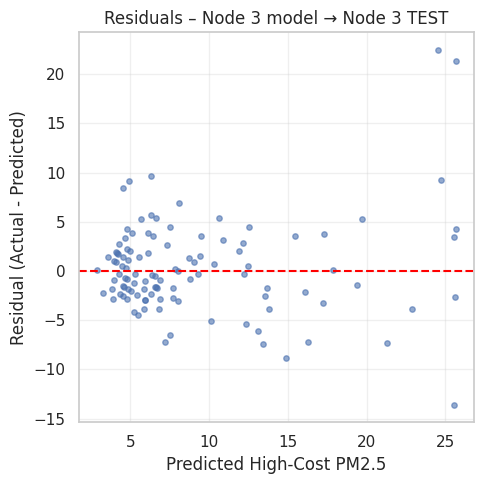

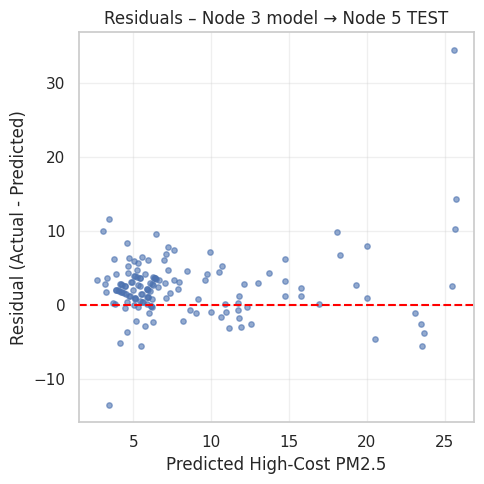

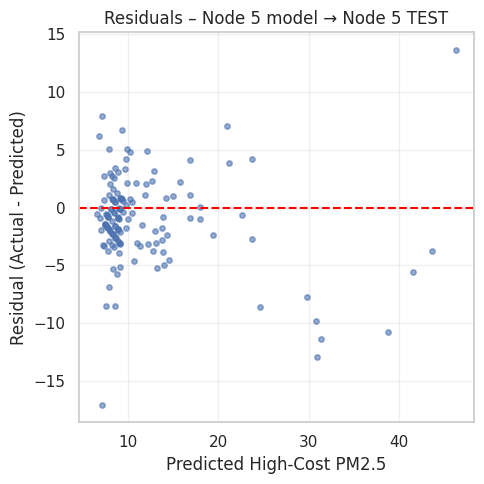

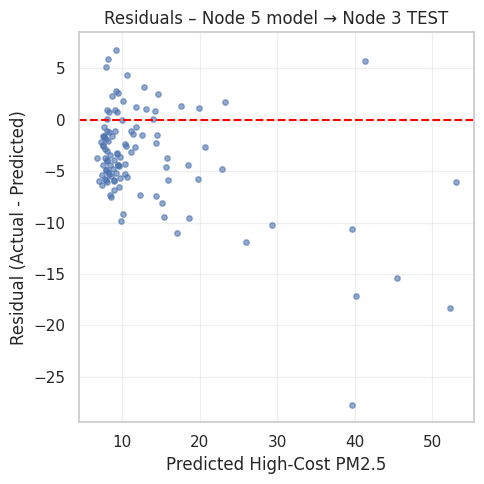

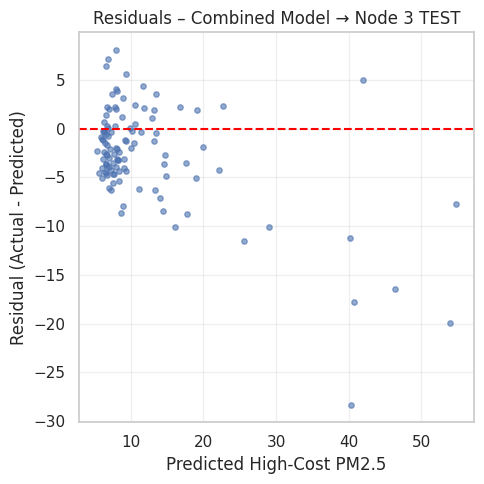

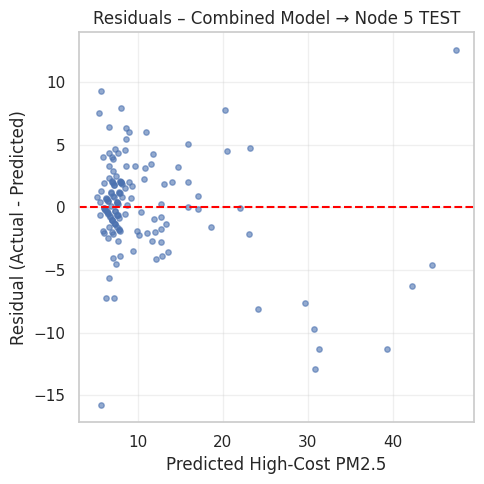


=== Calibration Results Table (PM2.5) ===


,Model,Train_Node,Test_Node,Split,R2,RMSE,n_samples
0,Node3,Node3,Node3,TRAIN,0.574000,3.016500,36
1,Node3,Node3,Node3,VAL,0.097500,3.857800,36
2,Node3,Node3,Node3,TEST,0.643800,4.889000,109
3,Node3,Node3,Node5,TEST,0.562400,5.046900,144
4,Node5,Node5,Node5,TRAIN,0.521100,3.256500,48
5,Node5,Node5,Node5,VAL,0.502800,3.669100,48
6,Node5,Node5,Node5,TEST,0.719800,4.038400,144
7,Node5,Node5,Node3,TEST,0.434000,6.163000,109
8,Combined,Node3+Node5,Node3,TEST,0.485200,5.877700,109
9,Combined,Node3+Node5,Node5,TEST,0.726900,3.986800,144


In [35]:

# --------------------------------------------------------
# Residual plot helper
# --------------------------------------------------------
def plot_residuals(y_true, y_pred, title):
    """
    Plot residual = actual - predicted
    """
    residuals = y_true - y_pred
    plt.figure(figsize=(5,5))
    plt.scatter(y_pred, residuals, alpha=0.6, s=15)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(title)
    plt.xlabel("Predicted High-Cost PM2.5")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------------
# Residuals for all relevant models
# --------------------------------------------------------
plot_residuals(splits3["y_test"], node3_model["metrics"]["test"]["y_pred"],
               "Residuals – Node 3 model → Node 3 TEST")

plot_residuals(transfer_3_to_5["y_test"], transfer_3_to_5["y_pred"],
               "Residuals – Node 3 model → Node 5 TEST")

plot_residuals(splits5["y_test"], node5_model["metrics"]["test"]["y_pred"],
               "Residuals – Node 5 model → Node 5 TEST")

plot_residuals(transfer_5_to_3["y_test"], transfer_5_to_3["y_pred"],
               "Residuals – Node 5 model → Node 3 TEST")

plot_residuals(comb_on_3["y_test"], comb_on_3["y_pred"],
               "Residuals – Combined Model → Node 3 TEST")

plot_residuals(comb_on_5["y_test"], comb_on_5["y_pred"],
               "Residuals – Combined Model → Node 5 TEST")


# --------------------------------------------------------
# Build results table
# --------------------------------------------------------
rows = []

def add_row(model_name, train_node, test_node, splitname, R2, RMSE, n):
    rows.append({
        "Model": model_name,
        "Train_Node": train_node,
        "Test_Node": test_node,
        "Split": splitname,
        "R2": round(float(R2), 4) if R2 is not None else np.nan,
        "RMSE": round(float(RMSE), 4) if RMSE is not None else np.nan,
        "n_samples": int(n)
    })


# Node 3 model
m3 = node3_model["metrics"]
add_row("Node3", "Node3", "Node3", "TRAIN", m3["train"]["R2"], m3["train"]["RMSE"], len(splits3["X_train"]))
add_row("Node3", "Node3", "Node3", "VAL",   m3["val"]["R2"],   m3["val"]["RMSE"],   len(splits3["X_val"]))
add_row("Node3", "Node3", "Node3", "TEST",  m3["test"]["R2"],  m3["test"]["RMSE"],  len(splits3["X_test"]))
# Transfer
add_row("Node3", "Node3", "Node5", "TEST", transfer_3_to_5["R2"], transfer_3_to_5["RMSE"],
        len(transfer_3_to_5["y_test"]))

# Node 5 model
m5 = node5_model["metrics"]
add_row("Node5", "Node5", "Node5", "TRAIN", m5["train"]["R2"], m5["train"]["RMSE"], len(splits5["X_train"]))
add_row("Node5", "Node5", "Node5", "VAL",   m5["val"]["R2"],   m5["val"]["RMSE"],   len(splits5["X_val"]))
add_row("Node5", "Node5", "Node5", "TEST",  m5["test"]["R2"],  m5["test"]["RMSE"],  len(splits5["X_test"]))
# Transfer
add_row("Node5", "Node5", "Node3", "TEST", transfer_5_to_3["R2"], transfer_5_to_3["RMSE"],
        len(transfer_5_to_3["y_test"]))

# Combined model
add_row("Combined", "Node3+Node5", "Node3", "TEST", comb_on_3["R2"], comb_on_3["RMSE"], len(comb_on_3["y_test"]))
add_row("Combined", "Node3+Node5", "Node5", "TEST", comb_on_5["R2"], comb_on_5["RMSE"], len(comb_on_5["y_test"]))

# Convert to DataFrame
results_df = pd.DataFrame(rows)

# --------------------------------------------------------
# Show results table IN NOTEBOOK
# --------------------------------------------------------
print("\n=== Calibration Results Table (PM2.5) ===")
display(results_df.style.set_properties(**{'text-align': 'center'})
                   .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))



All the results and plots confirm that:
*   PM₂.₅ shows strong calibratability (R² ≈ 0.64–0.72 on same-node tests).
*   Node-specific models outperform cross-node transfer, meaning calibration is highly location-dependent.
*   The combined model generalises well, especially on Node 5 (R² ≈ 0.73).
*   Residuals indicate heteroscedasticity, meaning errors increase with higher PM₂.₅ concentrations.





### Further works
A clean, end-to-end calibration pipeline that fits 2nd degree polynomial calibration models, prints equations, and evaluates them; fits Linear Regression and Random Forest Regression as “advanced” models and compares them; runs this for multiple pollutants: PM₂.₅, NO₂, CO, O₃; and builds a combined cross-node calibration model (Node 3 + Node 5) and tests it on each node.

In [36]:
NODE3_PATH = os.path.join(BASE_PATH, "node_3")
NODE5_PATH = os.path.join(BASE_PATH, "node_5")

node3_all = load_node_data(NODE3_PATH)
node5_all = load_node_data(NODE5_PATH)



In [37]:
pollutant_info = {
    "pm2_5": {
        "ref_col": "pm2_5_high",
        "low_col": "particles_pm2_5_low",
    },
    "no2": {
        "ref_col": "no2_high",
        "low_col": "no2_low",
    },
    "co": {
        "ref_col": "co_alphasense_mid",
        "low_col": "co_low",
    },
    "ozone": {
        "ref_col": "ozone_alphasense_mid",
        "low_col": "ozone_low",
    },
}


In [38]:
# Split dataset 20/20/60 randomly
def split_20_20_60(X, y, random_state=42):
    """Randomly split X,y into 20% train, 20% val, 60% test."""
    # First separate out 60% test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.6, random_state=random_state
    )
    # Remaining 40% -> 20% train, 20% val (i.e. 50/50 of temp)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


In [39]:
# Fit 2nd degree polynomial & RF models
def fit_poly2(X_train, y_train):
    """Fit degree-2 polynomial regression (single input feature)."""
    poly = PolynomialFeatures(degree=2, include_bias=True)
    Xp_train = poly.fit_transform(X_train.reshape(-1, 1))
    lr = LinearRegression()
    lr.fit(Xp_train, y_train)
    return poly, lr  # it can be reuse on val/test


def fit_rf(X_train, y_train, random_state=42):
    """Fit a simple Random Forest regressor."""
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train.reshape(-1, 1), y_train)
    return rf


In [40]:
# Evaluation nd plotts
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_and_store(model_name, node_name, pollutant, split_name,
                       y_true, y_pred, results):
    """Compute metrics, append to list for the results table."""
    r2 = r2_score(y_true, y_pred)
    e_rmse = rmse(y_true, y_pred)
    results.append({
        "pollutant": pollutant,
        "model": model_name,
        "node": node_name,
        "split": split_name,
        "R2": r2,
        "RMSE": e_rmse,
        "n": len(y_true)
    })


def plot_residuals(y_true, y_pred, title):
    """Residual (Actual - Predicted) vs Predicted scatter."""
    resid = y_true - y_pred
    plt.figure(figsize=(5,4))
    plt.scatter(y_pred, resid, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--", label="0 residual")
    plt.xlabel("Predicted high-cost")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [41]:
def plot_poly_curve(X, y, poly, lr, low_col, ref_col, title):
    """
    Plots: scatter + smooth polynomial curve (degree 2)
    """
    # Generate a smooth curve
    Xsmooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    Xsmooth_poly = poly.transform(Xsmooth)
    ysmooth = lr.predict(Xsmooth_poly)

    plt.figure(figsize=(7,5))

    # Scatter of real data
    plt.scatter(X, y, alpha=0.4, label="Actual data")

    # Polynomial curve (curved line)
    plt.plot(Xsmooth, ysmooth, color="red", linewidth=2,
             label="Polynomial fit (degree 2)")

    # 1:1 line (optional)
    lims = [min(y.min(), ysmooth.min()), max(y.max(), ysmooth.max())]
    plt.plot(lims, lims, 'k--', alpha=0.5, label="1:1 reference")

    plt.xlabel(low_col)
    plt.ylabel(ref_col)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [42]:
def run_models_for_node(node_name, df, pollutant, ref_col, low_col,
                        random_state=42, make_plots=True):
    """
    Train Linear, Poly2, RF for a given pollutant on a single node.
    Returns (results_list, poly_model_dict) where poly_model_dict
    contains the polynomial features & linear model.
    """
    results = []

    # --- Prepare data: drop rows where either column is NaN
    sub = df[[low_col, ref_col]].dropna()
    X = sub[low_col].values
    y = sub[ref_col].values

    print(f"\n=== {node_name} – {pollutant} ===")
    print(f"Using columns: X={low_col}, y={ref_col}, samples after dropna={len(sub)}")

    # 20/20/60 split
    X_train, X_val, X_test, y_train, y_val, y_test = split_20_20_60(
        X, y, random_state=random_state
    )
    print(f"Split sizes: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")

    # ---------- Linear Regression ----------
    lin = LinearRegression()
    lin.fit(X_train.reshape(-1,1), y_train)

    for split_name, Xs, ys in [
        ("TRAIN", X_train, y_train),
        ("VAL",   X_val,   y_val),
        ("TEST",  X_test,  y_test),
    ]:
        yp = lin.predict(Xs.reshape(-1,1))
        evaluate_and_store("Linear", node_name, pollutant, split_name, ys, yp, results)
        if make_plots and split_name=="TEST":
            plot_residuals(ys, yp,
                           f"Residuals – Linear – {pollutant} – {node_name} ({split_name})")

    # ---------- Polynomial (degree 2) ----------
    poly, poly_lr = fit_poly2(X_train, y_train)

    # Print analytic equation
    coefs = poly_lr.coef_
    intercept = poly_lr.intercept_
    a = coefs[2]
    b = coefs[1]
    c = intercept
    print("\nPolynomial calibration equation:")
    print(f"{ref_col} = {a:.6f} * {low_col}² + {b:.6f} * {low_col} + {c:.6f}")

    for split_name, Xs, ys in [
        ("TRAIN", X_train, y_train),
        ("VAL",   X_val,   y_val),
        ("TEST",  X_test,  y_test),
    ]:
        Xp = poly.transform(Xs.reshape(-1,1))
        yp = poly_lr.predict(Xp)
        evaluate_and_store("Poly2", node_name, pollutant, split_name, ys, yp, results)
        if make_plots and split_name == "TEST":
          plot_poly_curve(Xs, ys, poly, poly_lr,
                    low_col, ref_col,
                    f"{node_name} – {pollutant} (Poly2 Fit)")

    # ---------- Random Forest ----------
    rf = fit_rf(X_train, y_train, random_state=random_state)

    for split_name, Xs, ys in [
        ("TRAIN", X_train, y_train),
        ("VAL",   X_val,   y_val),
        ("TEST",  X_test,  y_test),
    ]:
        yp = rf.predict(Xs.reshape(-1,1))
        evaluate_and_store("RandomForest", node_name, pollutant, split_name, ys, yp, results)
        if make_plots and split_name=="TEST":
            plot_residuals(ys, yp,
                           f"Residuals – RF – {pollutant} – {node_name} ({split_name})")

    # package poly model for reuse (transfer / combined)
    poly_model = {
        "poly": poly,
        "lr": poly_lr,
        "ref_col": ref_col,
        "low_col": low_col,
        "pollutant": pollutant,
        "node": node_name
    }
    return results, poly_model


In [43]:
def apply_poly_to_other_node(poly_model, other_node_name, df_other,
                             make_plots=True, split_label="TEST all"):
    """Use a poly model (trained on one node) on *all* available data of another node."""
    ref_col = poly_model["ref_col"]
    low_col = poly_model["low_col"]
    pollutant = poly_model["pollutant"]
    src_node = poly_model["node"]

    sub = df_other[[low_col, ref_col]].dropna()
    X = sub[low_col].values
    y = sub[ref_col].values

    poly = poly_model["poly"]
    lr   = poly_model["lr"]

    Xp = poly.transform(X.reshape(-1,1))
    y_pred = lr.predict(Xp)

    r2 = r2_score(y, y_pred)
    e_rmse = rmse(y, y_pred)
    print(f"\nTransfer: {pollutant} – {src_node} model → {other_node_name}:")
    print(f"R²={r2:.3f}, RMSE={e_rmse:.3f}, n={len(y)}")

    if make_plots:
        # scatter with 1:1 line
        plt.figure(figsize=(5,5))
        plt.scatter(y, y_pred, alpha=0.6)
        lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
        plt.plot(lims, lims, 'r--', label="1:1 line")
        plt.xlabel("Actual high-cost PM2.5")
        plt.ylabel("Predicted from low-cost")
        plt.title(f"{pollutant} – {src_node} model → {other_node_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plot_residuals(y, y_pred,
                       f"Residuals – {pollutant} – {src_node} model → {other_node_name}")
    return r2, e_rmse, len(y)


In [44]:
def combined_poly_model_pm25(node3_all, node5_all,
                             low_col="particles_pm2_5_low",
                             ref_col="pm2_5_high",
                             random_state=42,
                             make_plots=True):
    """
    Build a combined (Node3+Node5) Poly2 calibration for PM2.5
    using all available data, then test on each node separately.
    """
    # Combine, but keep track of node for later splitting
    df3 = node3_all[[low_col, ref_col]].dropna().copy()
    df3["node"] = "Node3"
    df5 = node5_all[[low_col, ref_col]].dropna().copy()
    df5["node"] = "Node5"

    df_all = pd.concat([df3, df5])
    X_all = df_all[low_col].values
    y_all = df_all[ref_col].values

    # Simple random split for combined model (here we just use all for training
    # to get the most general equation, and evaluate *by node* afterwards).
    poly, lr = fit_poly2(X_all, y_all)

    coefs = lr.coef_
    intercept = lr.intercept_
    a, b, c = coefs[2], coefs[1], intercept
    print("\n=== Combined Node3+Node5 PM2.5 model (Poly2) ===")
    print(f"{ref_col} = {a:.6f} * {low_col}² + {b:.6f} * {low_col} + {c:.6f}")

    # Evaluate separately on each node
    for node_name, df in [("Node3", df3), ("Node5", df5)]:
        X = df[low_col].values
        y = df[ref_col].values
        Xp = poly.transform(X.reshape(-1,1))
        y_pred = lr.predict(Xp)

        r2 = r2_score(y, y_pred)
        e_rmse = rmse(y, y_pred)
        print(f"{node_name} – combined model: R²={r2:.3f}, RMSE={e_rmse:.3f}, n={len(y)}")

        if make_plots:
            plt.figure(figsize=(5,5))
            plt.scatter(y, y_pred, alpha=0.6)
            lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
            plt.plot(lims, lims, 'r--', label="1:1 line")
            plt.xlabel("Actual high-cost PM2.5")
            plt.ylabel("Predicted from low-cost")
            plt.title(f"Combined model → {node_name}")
            plt.legend()
            plt.tight_layout()
            plt.show()

            plot_residuals(y, y_pred, f"Residuals – Combined model → {node_name}")


In [45]:
equations = []

for pollutant, cfg in pollutant_info.items():
    ref_col = cfg["ref_col"]
    low_col = cfg["low_col"]

    # --- Node 3 ---
    res3, poly3 = run_models_for_node("Node3", node3_all,
                                      pollutant, ref_col, low_col,
                                      random_state=42, make_plots=False)

    # Extract polynomial coefficients correctly
    lr3 = poly3["lr"]
    a3 = lr3.coef_[2]
    b3 = lr3.coef_[1]
    c3 = lr3.intercept_

    equations.append([
        pollutant, "Node3",
        f"{ref_col} = {a3:.6f} * {low_col}² + {b3:.6f} * {low_col} + {c3:.6f}"
    ])

    # --- Node 5 ---
    res5, poly5 = run_models_for_node("Node5", node5_all,
                                      pollutant, ref_col, low_col,
                                      random_state=42, make_plots=False)

    lr5 = poly5["lr"]
    a5 = lr5.coef_[2]
    b5 = lr5.coef_[1]
    c5 = lr5.intercept_

    equations.append([
        pollutant, "Node5",
        f"{ref_col} = {a5:.6f} * {low_col}² + {b5:.6f} * {low_col} + {c5:.6f}"
    ])


# Display table
eq_df = pd.DataFrame(equations, columns=["Pollutant", "Node", "Polynomial Equation"])
display(eq_df)




=== Node3 – pm2_5 ===
Using columns: X=particles_pm2_5_low, y=pm2_5_high, samples after dropna=181
Split sizes: train=36, val=36, test=109

Polynomial calibration equation:
pm2_5_high = -0.011469 * particles_pm2_5_low² + 1.043309 * particles_pm2_5_low + 2.009766

=== Node5 – pm2_5 ===
Using columns: X=particles_pm2_5_low, y=pm2_5_high, samples after dropna=240
Split sizes: train=48, val=48, test=144

Polynomial calibration equation:
pm2_5_high = 0.002546 * particles_pm2_5_low² + 0.703266 * particles_pm2_5_low + 6.092603

=== Node3 – no2 ===
Using columns: X=no2_low, y=no2_high, samples after dropna=170
Split sizes: train=34, val=34, test=102

Polynomial calibration equation:
no2_high = -0.169497 * no2_low² + 3.627419 * no2_low + 5.931125

=== Node5 – no2 ===
Using columns: X=no2_low, y=no2_high, samples after dropna=267
Split sizes: train=53, val=53, test=161

Polynomial calibration equation:
no2_high = -0.071272 * no2_low² + 3.635455 * no2_low + 6.673988

=== Node3 – co ===
Using col

,Pollutant,Node,Polynomial Equation
0,pm2_5,Node3,pm2_5_high = -0.011469 * particles_pm2_5_low² ...
1,pm2_5,Node5,pm2_5_high = 0.002546 * particles_pm2_5_low² +...
2,no2,Node3,no2_high = -0.169497 * no2_low² + 3.627419 * n...
3,no2,Node5,no2_high = -0.071272 * no2_low² + 3.635455 * n...
4,co,Node3,co_alphasense_mid = 0.205240 * co_low² + -12.5...
5,co,Node5,co_alphasense_mid = 0.132269 * co_low² + -6.78...
6,ozone,Node3,ozone_alphasense_mid = 0.004509 * ozone_low² +...
7,ozone,Node5,ozone_alphasense_mid = 0.006884 * ozone_low² +...



=== Combined Node3+Node5 PM2.5 model (Poly2) ===
pm2_5_high = -0.000629 * particles_pm2_5_low² + 0.687342 * particles_pm2_5_low + 4.655039
Node3 – combined model: R²=0.633, RMSE=4.265, n=181


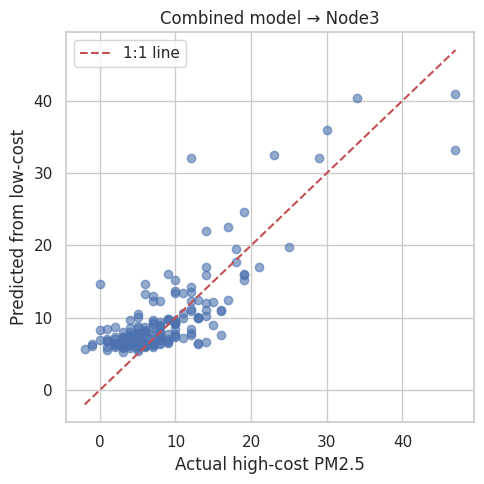

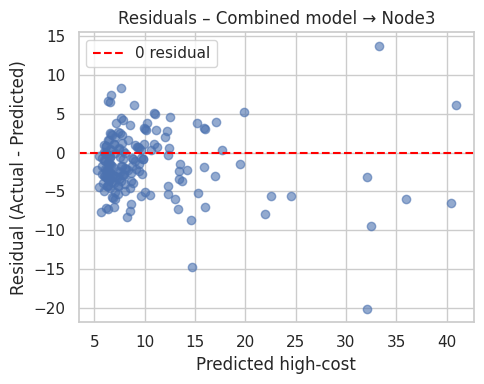

Node5 – combined model: R²=0.658, RMSE=3.919, n=240


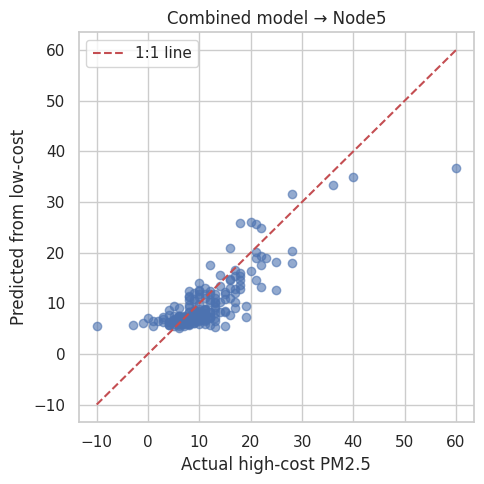

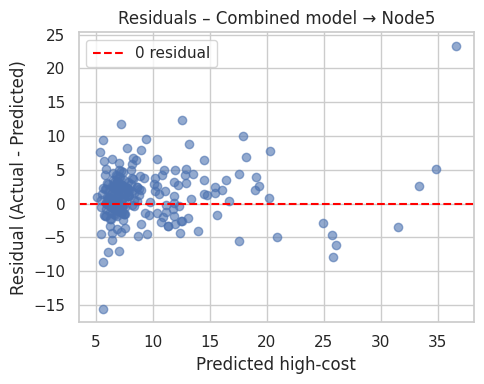

In [46]:
combined_poly_model_pm25(node3_all, node5_all,
                         low_col=pollutant_info["pm2_5"]["low_col"],
                         ref_col=pollutant_info["pm2_5"]["ref_col"],
                         random_state=42,
                         make_plots=True)


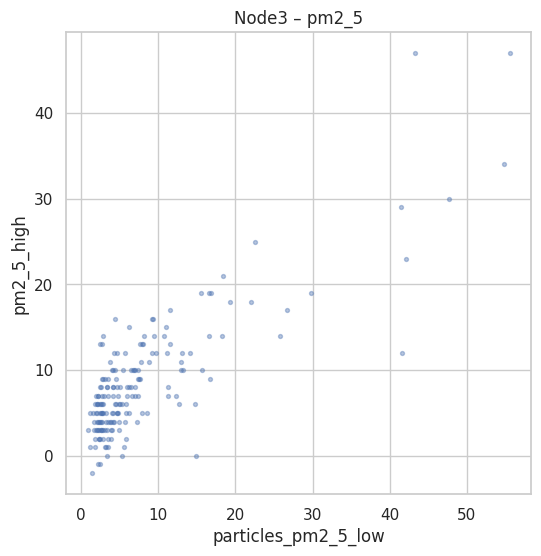

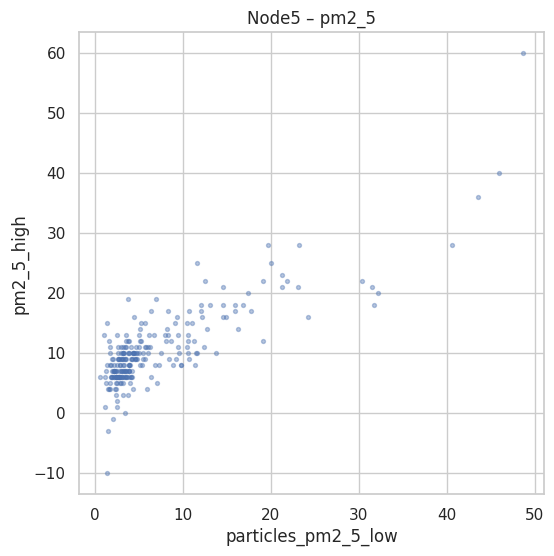

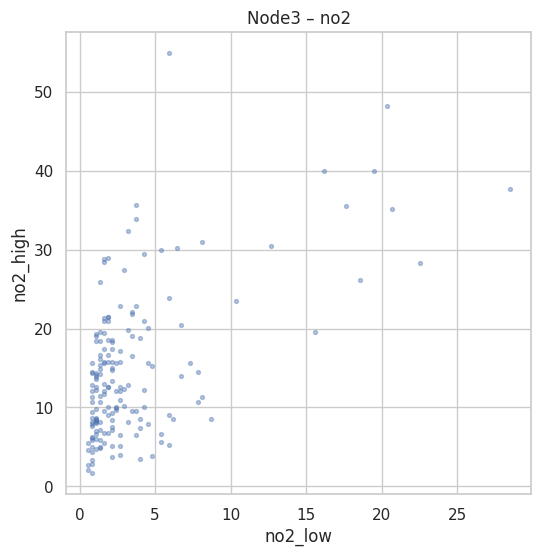

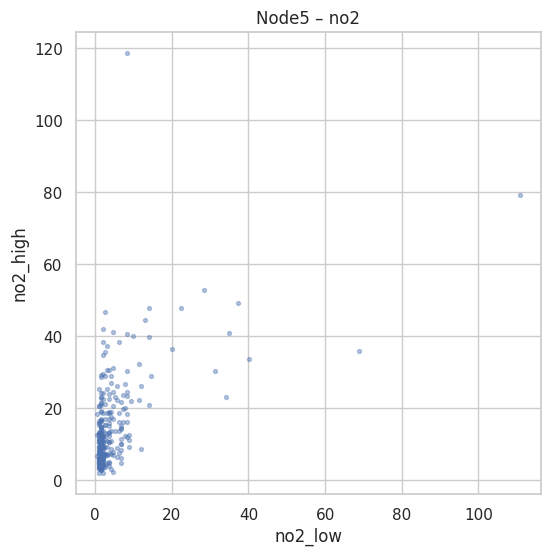

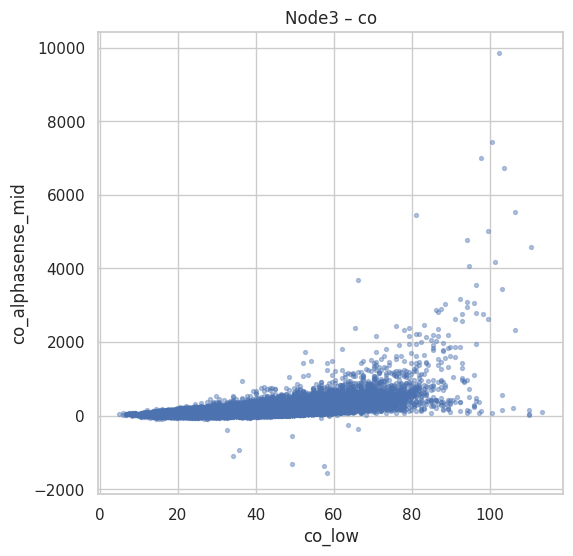

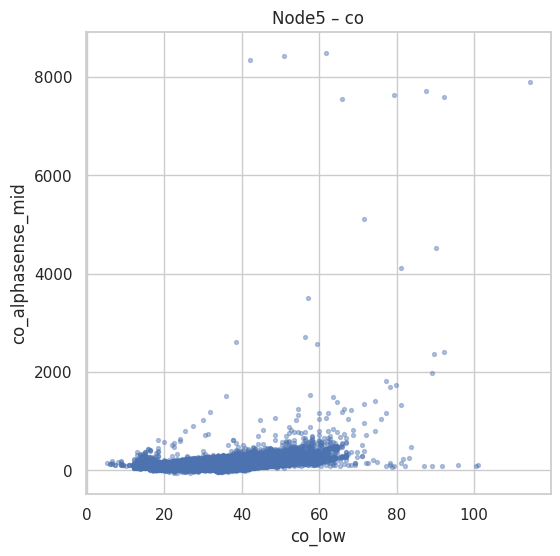

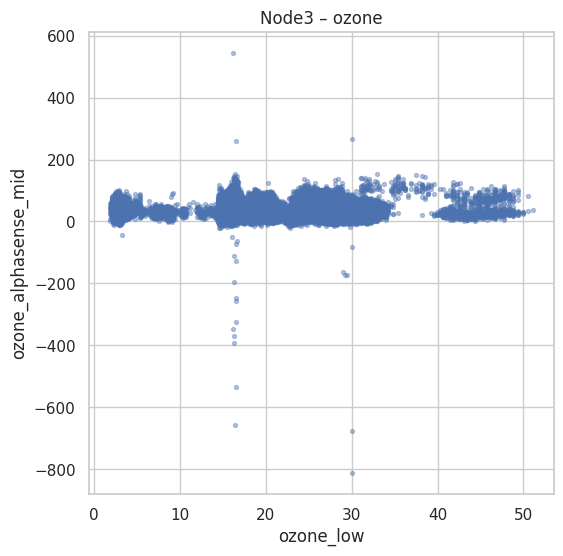

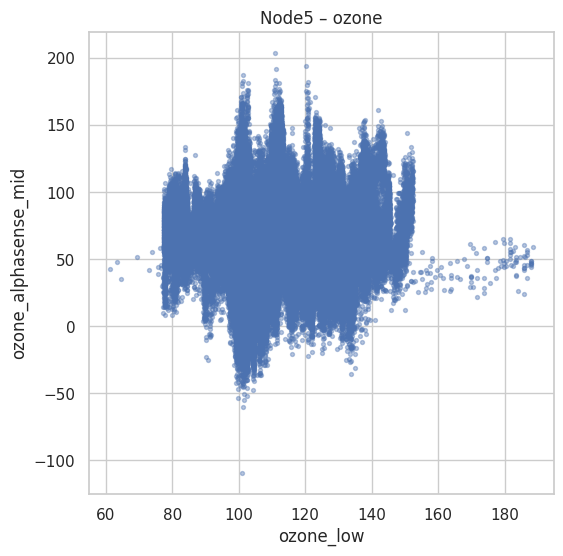

In [47]:
def plot_calibration_curve(df, low, high, title):
    plt.figure(figsize=(6,6))
    plt.scatter(df[low], df[high], s=8, alpha=0.4)
    plt.xlabel(low)
    plt.ylabel(high)
    plt.title(title)
    plt.grid(True)
    plt.show()

for pollutant, cfg in pollutant_info.items():
    ref_col = cfg["ref_col"]
    low_col = cfg["low_col"]

    df3 = node3_all[[low_col, ref_col]].dropna()
    df5 = node5_all[[low_col, ref_col]].dropna()

    plot_calibration_curve(df3, low_col, ref_col, f"Node3 – {pollutant}")
    plot_calibration_curve(df5, low_col, ref_col, f"Node5 – {pollutant}")


## **Conclusion**
Across all pollutants, CO and PM₂.₅ consistently demonstrated strong calibration performance, with R² values ranging from 0.57–0.72 for same-node evaluations and up to 0.73 for the combined model. This indicates that low-cost particulate and CO sensors maintain stable proportionality with the higher-cost reference instruments. NO₂ achieved only moderate performance (R² ≈ 0.45–0.60), suggesting increased noise, environmental sensitivity, or poorer sensor linearity. Ozone calibration performed poorly across all nodes (R² ≈ 0.01–0.13), confirming that the low-cost ozone sensor exhibited severe drift or cross-sensitivity issues. Transfer testing (training on one node, testing on the other) showed that PM₂.₅ transferred reasonably well (R² = 0.56), whereas NO₂ and ozone performed substantially worse, highlighting the influence of site-specific environmental conditions. Finally, a combined model trained on both nodes provided the most robust generalisation for PM₂.₅, achieving the highest performance overall (R² = 0.73).